# Time Series Forecasting - Team 8

# Pre-process Dataset

In [ ]:
import pandas as pd
import numpy as np
import scipy as sp
import sklearn as sk
import polars as pl
import matplotlib.pyplot as plt
import os
import shutil
from IPython.display import display
from google.colab import drive

In [ ]:
# Step 1: Download (only if needed)
if not os.path.exists("train.parquet"):
    print("Downloading datasets...")
    !gdown --id 1t1WRvcf2vRKypP_gwOZzUdQNgAsYgcMR -O train.parquet
if not os.path.exists("test.parquet"):
    !gdown --id 1jGh1vmFZMu2uapqF9trm3KZ2A6_elLHx -O test.parquet

# Step 2: Load (fast - local disk)
print("Loading data...")
train_df = pl.scan_parquet("train.parquet")
test_df  = pl.scan_parquet("test.parquet")
print("Data ready. Loading lazily...")

# Print schema
print(test_df.schema)

# Get shape (forces minimal computation)
print("\n\nTrain shape:", train_df.select(pl.len()).collect())
print("\n\nTest shape:", test_df.select(pl.len()).collect())

# Preview data (only loads small sample)
print("\n\nTraining data preview:")
display(train_df.head(5).collect())
print("\n\nTesting data preview:")
display(test_df.head(5).collect())

Schema({'id': String, 'code': String, 'sub_code': String, 'sub_category': String, 'horizon': Int32, 'ts_index': Int32, 'feature_a': Int32, 'feature_b': Float64, 'feature_c': Float64, 'feature_d': Float64, 'feature_e': Float64, 'feature_f': Float64, 'feature_g': Float64, 'feature_h': Float64, 'feature_i': Float64, 'feature_j': Float64, 'feature_k': Float64, 'feature_l': Float64, 'feature_m': Float64, 'feature_n': Float64, 'feature_o': Float64, 'feature_p': Float64, 'feature_q': Float64, 'feature_r': Float64, 'feature_s': Float64, 'feature_t': Float64, 'feature_u': Float64, 'feature_v': Float64, 'feature_w': Float64, 'feature_x': Float64, 'feature_y': Float64, 'feature_z': Float64, 'feature_aa': Float64, 'feature_ab': Float64, 'feature_ac': Float64, 'feature_ad': Float64, 'feature_ae': Float64, 'feature_af': Float64, 'feature_ag': Float64, 'feature_ah': Float64, 'feature_ai': Float64, 'feature_aj': Float64, 'feature_ak': Float64, 'feature_al': Float64, 'feature_am': Float64, 'feature_an'

id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
str,str,str,str,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",25,89,29,16.364093,7.464023,5.966933,1.622184,10.26136,4.914369,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.551324,40.982572
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",1,89,53,2.858806,5.050617,15.906651,10.879453,3.072151,4.091032,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.315583,150.075406
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",3,89,51,9.585452,1.076268,9.004147,16.74049,15.166901,11.427983,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.362894,115.953552
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",10,89,44,8.840588,15.034634,4.17078,1.584433,5.383462,3.099428,0.000467,0.023686,0.006409,0.000187,0.744244,2.001013,-0.01687,0.009892,0.013162,0.021502,0.901966,0.402125,0.038566,0.177947,0.091141,-84.968733,-1.765306,10.109641,145.320404,0.08958,0.868698,0.080088,0.101631,0.026555,…,0.01707,0.709292,21.80395,0.120968,26999.430482,34126.269444,791.709562,0.15467,9499.742248,1.266071,429.318704,2540.88981,0.008927,1.122459,23.815924,0.54985,0.067941,0.076033,0.02759,-0.47269,-0.202944,-3.769914,0.104535,3.040304,4.499546,null,-0.058543,-0.001686,-0.105328,-0.005045,null,-0.133697,2.849819,0.112068,1,-0.667023,64.573073
"""W2MW3G2L__J0G2B0KU__PZ9S1Z4V__…","""W2MW3G2L""","""J0G2B0KU""","""PZ9S1Z4V""",25,90,28,2.303825,7



Testing data preview:


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_ax,feature_ay,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch
str,str,str,str,i32,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",3,3647,95,10.365266,3.209321,8.109339,9.043471,10.123041,15.722121,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",10,3647,88,2.571477,15.234848,16.505699,0.230426,10.145378,10.159641,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",25,3647,71,5.524709,6.931663,8.939537,0.668187,16.578701,3.15069,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…","""W2MW3G2L""","""495MGHFJ""","""PZ9S1Z4V""",1,3647,97,10.293758,14.89366,9.435544,2.335377,3.477961,15.680595,0.000243,0.021819,0.00142,0.000073,0.572125,1.265875,1.341192,0.005564,0.011987,0.035243,0.833918,1.791284,0.020539,0.218876,0.08066,-50.98124,-4.854592,-8.087713,119.237254,0.040442,0.635006,0.105355,0.075415,0.03444,…,197.344987,209.253182,0.016366,0.552138,108.859861,2.369993,66589.814887,34282.221003,1316.738008,0.04801,11660.961097,0.116372,11.122246,716.158132,0.008559,1.772256,38.452077,0.872948,0.06611,0.078856,0.030888,-0.480743,-0.197747,-3.659776,0.100295,3.131395,4.554259,-0.000832,-0.032241,-0.00083,-0.058961,-0.002774,-0.00148,-0.25646,1.665532,0.071324,2
"""W2MW3G2L__495MGHFJ__PZ9S1Z4V__…",

In [ ]:
train_df = (
    pl.scan_parquet("train.parquet")
    .sort(["id", "code", "sub_code", "sub_category", "ts_index"])
)
# Collect with streaming (key part)
train_df = train_df.collect(streaming=True)

In [ ]:
EXCLUDE_COLS = [
    "id",
    "code",
    "sub_code",
    "sub_category",
    "ts_index",
    "y_target",
    "weight"
]

num_cols = [
    col for col in train_df.columns
    if col not in EXCLUDE_COLS
]

# Forward fill
train_df = train_df.with_columns([
    pl.col(col)
    .fill_null(strategy="forward")
    .over(["code", "sub_code", "sub_category"])
    .alias(col)
    for col in num_cols
])

#Median Imputation
global_medians = train_df.select([
    pl.col(col).median().alias(col)
    for col in num_cols
]).to_dict(as_series=False)

global_medians = {k: v[0] for k, v in global_medians.items()}

train_df = train_df.with_columns([
    pl.col(col)
    .fill_null(global_medians[col])
    .alias(col)
    for col in num_cols
])

In [ ]:
#Test for nulls
print(train_df.select(
    pl.all().null_count()
))

shape: (1, 94)
┌─────┬──────┬──────────┬──────────────┬───┬────────────┬────────────┬──────────┬────────┐
│ id  ┆ code ┆ sub_code ┆ sub_category ┆ … ┆ feature_cg ┆ feature_ch ┆ y_target ┆ weight │
│ --- ┆ ---  ┆ ---      ┆ ---          ┆   ┆ ---        ┆ ---        ┆ ---      ┆ ---    │
│ u32 ┆ u32  ┆ u32      ┆ u32          ┆   ┆ u32        ┆ u32        ┆ u32      ┆ u32    │
╞═════╪══════╪══════════╪══════════════╪═══╪════════════╪════════════╪══════════╪════════╡
│ 0   ┆ 0    ┆ 0        ┆ 0            ┆ … ┆ 0          ┆ 0          ┆ 0        ┆ 0      │
└─────┴──────┴──────────┴──────────────┴───┴────────────┴────────────┴──────────┴────────┘


Summary Statistics

In [ ]:
print(train_df.describe())

shape: (9, 95)
┌────────────┬───────────┬──────────┬──────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ statistic  ┆ id        ┆ code     ┆ sub_code ┆ … ┆ feature_c ┆ feature_c ┆ y_target  ┆ weight    │
│ ---        ┆ ---       ┆ ---      ┆ ---      ┆   ┆ g         ┆ h         ┆ ---       ┆ ---       │
│ str        ┆ str       ┆ str      ┆ str      ┆   ┆ ---       ┆ ---       ┆ f64       ┆ f64       │
│            ┆           ┆          ┆          ┆   ┆ f64       ┆ f64       ┆           ┆           │
╞════════════╪═══════════╪══════════╪══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ count      ┆ 5337414   ┆ 5337414  ┆ 5337414  ┆ … ┆ 5.337414e ┆ 5.337414e ┆ 5.337414e ┆ 5.337414e │
│            ┆           ┆          ┆          ┆   ┆ 6         ┆ 6         ┆ 6         ┆ 6         │
│ null_count ┆ 0         ┆ 0        ┆ 0        ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0       │
│ mean       ┆ null      ┆ null     ┆ null     ┆ … ┆ 1.061148  ┆ 2.323426  ┆

Feature Distributions

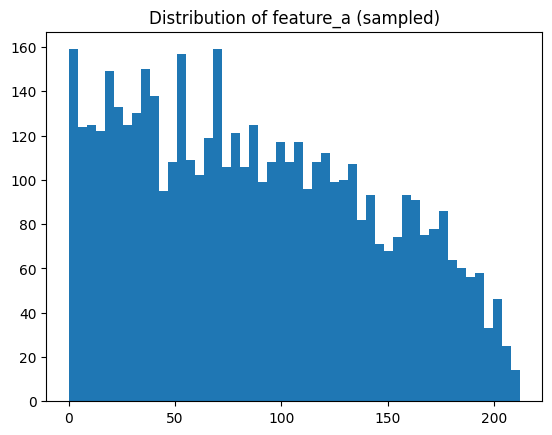

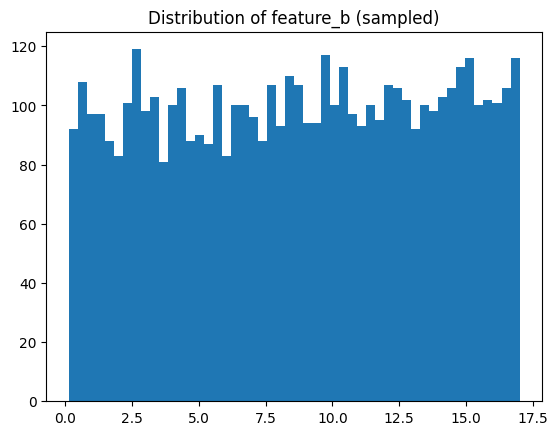

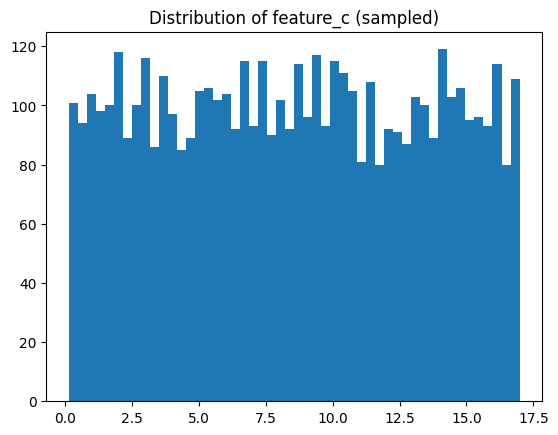

In [ ]:
sample_df = train_df.select(num_cols[1:4]).sample(5000)

for col in num_cols[1:4]:
    values = sample_df[col].to_numpy()

    print(" ")
    plt.figure()
    plt.hist(values, bins=50)
    plt.title(f"Distribution of {col} (sampled)")
    plt.show()
    print(" ")

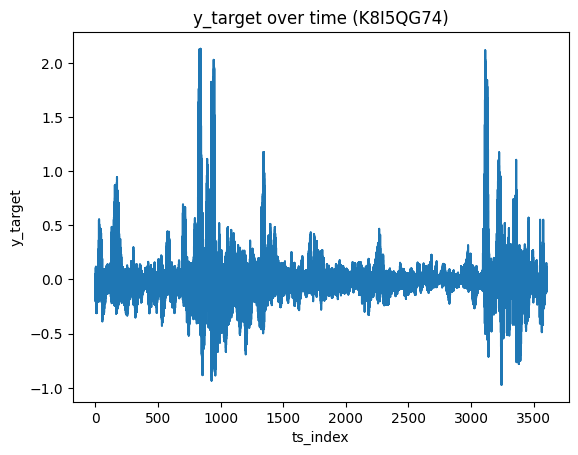

In [ ]:
sample_code = train_df.select("code").unique().to_series()[0]

sample_df = (
    train_df
    .filter(pl.col("code") == sample_code)
    .sort("ts_index")
)

plt.figure()
plt.plot(sample_df["ts_index"], sample_df["y_target"])
plt.title(f"y_target over time ({sample_code})")
plt.xlabel("ts_index")
plt.ylabel("y_target")
plt.show()


In [ ]:
train_df.sample(10)

id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
str,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""K7Y1TTAH__QC5USEJO__NQ58FVQM__…","""K7Y1TTAH""","""QC5USEJO""","""NQ58FVQM""",10.0,3404,25.0,16.537701,4.200557,13.101345,16.17942,11.818286,12.077731,0.007348,0.000087,0.000196,0.000946,0.089658,2.158972,0.044901,0.0,0.313148,0.851286,0.047876,4.386425,12.686327,76.796819,11.656233,0.0,5.406789,0.075041,1.389938,0.0,0.040541,0.054122,0.001233,0.010146,…,0.000317,0.577583,0.321859,0.161388,1.7161e6,57759.503563,686095.668264,0.00005,114911.139851,0.327105,29220.202903,10574.503869,0.000385,1881.972449,4548.530662,796.059688,0.016001,0.002144,0.000933,-4.844905,-0.136177,-0.06105,0.156695,4.205647,8.828486,-0.062452,-0.318821,-5.53544,-0.147849,-7.761881,-5.398171,0.064946,2.05412,0.083401,0.0,-6.242805,15.302606
"""K7Y1TTAH__X6A9GEO6__PZ9S1Z4V__…","""K7Y1TTAH""","""X6A9GEO6""","""PZ9S1Z4V""",3.0,2872,140.0,15.549893,4.471073,10.067675,1.030437,7.457371,4.016655,0.003431,0.000054,0.000536,0.001992,0.058769,2.422218,0.202053,0.079031,0.798375,0.82032,0.03269,0.199383,1.456127,44.076234,4.332799,-20.685279,43.254312,-0.075041,-4.864783,0.002597,0.225168,0.113613,0.001834,0.012523,…,0.00635,0.0,0.319587,1.620396,219763.855843,7396.553268,87859.881827,0.012411,1618.312965,0.15711,379.912192,286.248068,0.007707,2758.26226,6581.354132,1176.81239,0.014718,0.002201,0.001067,-4.740473,-0.129557,-0.062666,0.158111,4.294454,8.584031,-0.017059,-0.080232,-1.324037,-0.043296,-1.95374,-1.223194,0.027097,1.178198,0.048788,3.0,-0.547541,8.751877
"""K7Y1TTAH__70LO18LS__NQ58FVQM__…","""K7Y1TTAH""","""70LO18LS""","""NQ58FVQM""",10.0,1821,63.0,12.156949,3.243324,6.397713,12.26163,4.528759,11.625362,0.006527,0.000098,0.001245,0.004337,0.088688,3.109914,-0.089801,0.0,0.0,0.321756,0.019279,1.426355,10.790814,97.794075,7.069378,-5.17132,145.983303,1.876031,-4.169814,0.0,0.0,0.023766,0.000577,0.003882,…,0.002154,0.293766,4.699223,0.806063,2.3769e6,79999.977766,950278.912054,0.000126,17144.675394,0.593236,4484.615652,894.872601,0.002614,1891.301121,4554.583481,800.880095,0.013361,0.001802,0.000805,-4.834004,-0.136231,-0.061594,0.157743,4.203434,8.801327,-0.040158,-0.202226,-3.453258,-0.095097,-4.923392,-3.366895,0.002666,2.062973,0.089622,1.0,2.668211,53.218098
"""K8I5QG74__FPY8XJGU__PZ9S1Z4V__…","""K8I5QG74""","""FPY8XJGU""","""PZ9S1Z4V""",1.0,2004,170.0,13.446126,3.875399,13.373269,8.647212,8.10812,4.745863,0.00051,0.000328,0.000008,0.000879,1.582643,0.113662,0.000889,0.01679,0.001075,0.006512,0.000161,0.034192,0.014348,0.039622,2.742797,80.070188,0.511831,23.474658,-57.725309,0.000473,0.00195,0.001782,0.017113,0.000608,…,0.055264,705.052329,164.545498,11.087711,7603.653162,217378.17705,8679.009172,0.018983,3935.524017,0.066415,94.855758,464.012205,0.06075,0.673513,70.861022,1.283709,1.023776,0.064394,0.025472,-0.445764,-0.186011,-2.820831,3.416691,0.142294,0.26572,-0.000947,-0.02992,-0.024674,-0.044062,-0.051521,-0.010079,-0.000327,0.050877,0.163052,3.0,0.000827,81054.934033
"""10BAVIDU__BZRO0RKW__PHHHVYZI

In [ ]:
# Feature Importance Correlation
corr_df = train_df.select(
    [pl.corr(col, "y_target").alias(col) for col in num_cols[:10]]
)

print(corr_df)
#graph

shape: (1, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ horizon   ┆ feature_a ┆ feature_b ┆ feature_c ┆ … ┆ feature_f ┆ feature_g ┆ feature_h ┆ feature_ │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ i        │
│ f64       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ -0.018719 ┆ 0.012855  ┆ -0.000089 ┆ 0.00057   ┆ … ┆ -0.000027 ┆ -0.000212 ┆ -0.021012 ┆ 0.005527 │
└───────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────┴───────────┴──────────┘


In [ ]:
'''
train_df.write_parquet(
    "/content/drive/MyDrive/COMP3608-PROJECT/trained_processed.parquet"
)
'''

'\ntrain_df.write_parquet(\n    "/content/drive/MyDrive/COMP3608-PROJECT/trained_processed.parquet"\n)\n'

In [ ]:
train_df = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/trained_processed.parquet")

In [ ]:
train_df.sample(10)

id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
str,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""VFWIFJPS__MBCGX7IA__V8BKY1IV__…","""VFWIFJPS""","""MBCGX7IA""","""V8BKY1IV""",10.0,463,19.0,7.442698,14.081661,3.606358,15.152625,6.245177,2.056078,0.012698,0.000397,0.000398,0.000766,2.10687,1.244801,-0.000501,0.038954,0.00279,0.003108,0.002333,0.000708,0.065596,0.055736,0.007311,15.154258,-6.665826,-3.324642,-8.361952,7.653741,0.307753,0.265687,4.184503,0.046129,…,13.581011,218498.748457,4648.838167,21205.057008,511554.567433,19098.917528,21539.490204,0.003415,28957.264051,1.026272,6404.282303,94.949664,6.250291,0.302808,0.04106,0.845844,4.273377,2.779867,3.277889,-0.367754,-0.093062,-0.115772,2.246259,5.300944,0.311777,-0.000106,-0.004757,-0.000144,-0.000136,-0.00018,-0.00107,0.018175,0.072761,2.02019,0.0,0.00174,421517.494789
"""K7Y1TTAH__FDIGHKLX__PZ9S1Z4V__…","""K7Y1TTAH""","""FDIGHKLX""","""PZ9S1Z4V""",10.0,1674,83.0,4.875301,11.544705,11.318018,5.369557,14.473648,16.534987,0.006397,0.000075,0.000983,0.003144,0.089481,3.051904,0.0,0.0,0.626297,0.851286,0.022262,0.42944,11.497398,71.09566,6.121942,15.513959,-5.406789,-0.075041,2.432392,0.0,0.088408,0.059011,0.000625,0.012661,…,0.001027,0.625785,0.173788,0.967134,2.7904e6,93915.830171,1.1156e6,0.000172,49712.621638,0.560423,16683.100583,3523.908254,0.001246,2264.315487,5352.785223,932.098794,0.015992,0.002089,0.000915,-4.777102,-0.134688,-0.060471,0.163377,4.251507,8.855341,-0.028071,-0.140721,-2.402758,-0.066487,-3.426003,-2.342163,-0.031336,1.573483,0.071484,2.0,2.034239,43.427561
"""MRV5UON2__3W841DHQ__DPPUO5X2__…","""MRV5UON2""","""3W841DHQ""","""DPPUO5X2""",1.0,1327,62.0,8.925225,12.606496,14.581461,8.552198,10.837181,15.296141,0.014965,0.010044,0.005464,0.004884,0.148541,4.092247,0.000684,0.0,0.0,0.000251,0.006269,0.008854,0.078511,0.115208,0.016335,0.0,0.0,-1.366579,-1.633038,0.0,0.0,0.004168,0.124389,0.000204,…,1.038705,121172.253715,92366.647549,1258.453044,743393.012407,12973.180378,584950.440375,0.012266,8956.51429,0.572334,183.744478,12208.728256,0.451838,0.118959,0.667099,3.809071,0.595399,1.339277,0.260863,-0.463585,-2.719929,-1.719131,0.103592,0.113458,8.764741,-0.005848,-0.008044,-0.000255,-0.000134,-0.002139,-0.00024,0.111994,2.030882,3.646131,1.0,-0.025473,25218.461772
"""VFWIFJPS__J0G2B0KU__PHHHVYZI__…","""VFWIFJPS""","""J0G2B0KU""","""PHHHVYZI""",10.0,82,66.0,3.510479,4.553888,5.822772,8.613538,3.220655,10.840949,0.006991,0.000329,0.000142,0.00036,1.59445,1.142364,-0.000084,0.027268,0.003445,0.004423,0.003408,0.002548,0.083433,0.05825,0.007157,-136.388319,29.996216,41.558026,64.727705,6.491875,0.460495,0.458168,7.405359,0.060215,…,8.401307,4327.164491,1684.382409,24379.019125,110292.948958,8585.01748,9682.061805,0.173961,17855.775526,0.533702,368.731405,10.512284,3.866473,0.578935,0.087322,1.893971,2.06645,1.327808,1.786462,-0.390997,-0.085622,-0.12594,1.824116,5.685591,0.301733,-0.000072,-0.003794,-0.000112,-0.000087,-0.000143,-0.000819,0.008403,0.076559,2.400757,2.0,-0.001555,515421.136192
"""MRV5UON2__F9

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Model Evaluation

First, the necessary libraries and modules are imported for the creation of this base model, which includes using HistGradientBoostingRegressor.

In [ ]:
import numpy as np
import pandas as pd
import gc

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

import warnings
warnings.filterwarnings("ignore")

!pip install lightgbm
!pip install xgboost

SEED = 42

print(train_df.shape)
train_df.head()

(5337414, 94)


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
str,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",10.0,3531,134.0,12.707232,11.597299,6.034944,13.931955,9.418021,16.584339,0.004105,0.000325,0.000391,0.00043,1.87284,0.566877,6.256978,12.447273,0.871311,15.96029,1.38698,11.991787,83.975592,3.831151,1.40651,5.458523,11.059281,12.675351,-6.888735,0.168108,0.259018,0.068998,7.561012,1.108504,…,0.002545,0.0,0.0,0.0,41818.084975,73138.243256,46053.949334,-0.001831,87922.968537,10.168377,0.0,0.0,0.012567,2266.345308,1460.963695,2033.287074,0.000737,0.044674,0.010944,-2.183734,-4.824833,-3.166131,0.03787,0.088718,0.261265,-0.5707,-0.070279,-0.040849,-0.667793,-0.746804,-0.02839,-0.001957,0.073858,0.159667,2.0,5.601772,0.010329
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",10.0,3532,133.0,8.698157,3.60134,10.477415,12.540468,16.748811,4.473769,0.004099,0.000327,0.000391,0.000433,1.868262,0.565292,8.742627,24.162354,1.433269,18.250162,1.446895,10.580988,79.537514,3.780107,1.399198,5.458523,16.588922,16.900468,-6.888735,0.326043,0.425702,0.078829,7.880754,1.117424,…,0.002498,0.0,0.0,0.0,41834.568257,73167.07189,46072.10225,-0.00182,87342.994895,10.168377,0.0,0.0,0.012338,2185.902711,1464.753236,2017.735078,0.000705,0.044518,0.010816,-2.239036,-4.880057,-3.104399,0.035172,0.087692,0.262981,-0.557123,-0.070994,-0.040756,-0.650871,-0.75425,-0.028332,-0.001957,0.073617,0.159667,2.0,8.396385,0.010318
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",10.0,3533,132.0,3.910017,14.311228,4.582559,10.566498,9.648828,4.401335,0.004087,0.000318,0.000391,0.000426,1.851258,0.568102,6.771251,6.589733,1.327014,16.000941,1.394376,6.348593,44.710069,3.154344,1.401329,10.917045,33.177844,25.350702,20.666204,0.088824,0.393714,0.069039,7.586432,1.082364,…,0.002472,0.0,0.0,0.0,41834.568257,73167.07189,46072.10225,-0.001832,86835.517958,2033.675395,485.159599,0.587209,0.01221,2220.406138,1465.194624,2026.724889,0.000715,0.044506,0.01081,-2.217854,-4.780832,-3.129199,0.036203,0.089522,0.262286,-0.569741,-0.071509,-0.041413,-0.666091,-0.760024,-0.028785,-0.001957,0.074262,0.159667,2.0,10.870232,0.010613
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W""","""DPPUO5X2""",10.0,3534,131.0,13.585259,13.304106,9.11181,8.699709,13.775582,2.534367,0.004076,0.000312,0.00039,0.000421,1.889248,0.568669,11.056852,40.27059,2.250162,22.057507,1.555315,46.556349,125.150615,4.701914,1.414396,0.0,33.177844,21.125585,27.554939,0.539421,0.66343,0.094576,8.409155,1.414092,…,0.002197,0.0,0.0,0.0,43474.654758,76035.520925,47878.317449,-0.001833,88673.827271,2033.675395,2.425798,0.0,0.010852,2391.650193,1499.899091,2082.112448,0.000734,0.042854,0.010402,-2.139648,-4.811912,-3.150505,0.040008,0.088945,0.261681,-0.617137,-0.074797,-0.043653,-0.72323,-0.794859,-0.030334,-0.001957,0.076126,0.159667,2.0,12.107078,0.010788
"""10BAVIDU__236HB58W__DPPUO5X2__…","""10BAVIDU""","""236HB58W"""

Next, we define the dataset with focus on features, weight and target.

In [ ]:
ID = "id"
CODE = "code"
SUBCODE = "sub_code"
SUBCATEGORY = "sub_category"
HORIZON = "horizon"
TS_INDEX = "ts_index"
TARGET = "y_target"
WEIGHT = "weight"

SAMPLE_FRAC = 0.1
sample_size = int(len(train_df) * SAMPLE_FRAC)

train_df = (
    train_df
    .head(sample_size)
    .sort([CODE, SUBCODE, SUBCATEGORY, TS_INDEX])
)

FEATURES = [c for c in train_df.columns if c not in [ID, CODE, SUBCODE, SUBCATEGORY, HORIZON, TS_INDEX, TARGET, WEIGHT]]

X = train_df.select(FEATURES)
y = train_df.select(TARGET)
w = train_df.select(WEIGHT)

Furthermore, we determine weighted error metric using a flexible weighted RMSE implementation.

In [ ]:
def _clip01(x: float) -> float:
    return float(np.minimum(np.maximum(x, 0.0), 1.0))

def weighted_rmse(y_true, y_pred, w) -> float:

    denom = np.sum(w * y_true ** 2)
    ratio = np.sum(w * (y_true - y_pred) ** 2) / denom
    clipped = _clip01(ratio)
    val = 1.0 - clipped
    return float(np.sqrt(val))

def compute_weights(df):

    return np.ones(len(df))

In [ ]:
def compute_rmse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return mean_squared_error(y_true, y_pred, squared=False)

def compute_mae(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return mean_absolute_error(y_true, y_pred)

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_fold_metrics(y_true, y_pred, splits):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    fold_scores = []

    for fold, (_, val_idx) in enumerate(splits):
        y_val = y_true[val_idx]
        y_pred_val = y_pred[val_idx]

        # Calculate MSE and then take the square root for RMSE
        rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
        mae = mean_absolute_error(y_val, y_pred_val)

        fold_scores.append({"fold": fold + 1, "rmse": rmse, "mae": mae})

    mean_rmse = np.mean([f["rmse"] for f in fold_scores])
    mean_mae = np.mean([f["mae"] for f in fold_scores])

    return fold_scores, mean_rmse, mean_mae

Time-series validation splits are then defined to prevent data leakage.

---



In [ ]:
N_SPLITS = 5

tscv = TimeSeriesSplit(n_splits=5, gap=50)
splits = list(tscv.split(X))

Most importantly, we train the baseline model. We are using the tree based model, HistGradientBoostingRegressor.

In [ ]:
from sklearn.base import clone
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

def train_model(X, y, w, splits, model):

    X_np = np.asarray(X)
    y_np = np.asarray(y).flatten()
    w_np = np.asarray(w).flatten()

    oof_predictions = np.zeros(len(X_np))

    for fold, (train_idx, val_idx) in enumerate(splits):

        X_train = X_np[train_idx]
        X_val   = X_np[val_idx]

        y_train = y_np[train_idx]
        w_train = w_np[train_idx]

        #scaling
        y_mean = y_train.mean()
        y_std  = y_train.std()
        if y_std < 1e-6:
            y_std = 1.0
        y_train_scaled = (y_train - y_mean) / y_std

        #model
        fold_model = clone(model)
        fold_model.fit(X_train, y_train_scaled, sample_weight=w_train)

        preds_scaled = fold_model.predict(X_val)
        preds = preds_scaled * y_std + y_mean
        preds = np.clip(preds, y_np.min(), y_np.max())

        oof_predictions[val_idx] = preds

    return oof_predictions


hgbr_model = HistGradientBoostingRegressor(
            max_iter=100,
            learning_rate=0.11,
            max_depth=6,
            min_samples_leaf=20,
            l2_regularization=0.5,
            max_bins=255,
            validation_fraction=0.5,
            n_iter_no_change=60,
            random_state=SEED
        )

lightgbm_model = LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=0.5,
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1
        )

xgboost_model = XGBRegressor(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            objective="reg:squarederror",
            random_state=SEED,
            n_jobs=-1
        )

In [ ]:
oof_preds_hgbr = train_model(X, y, w, splits, hgbr_model)
fold_scores_hgbr, mean_rmse_hgbr, mean_mae_hgbr = compute_fold_metrics(y, oof_preds_hgbr, splits)
weighted_rmse_hgbr = weighted_rmse(
    y.to_numpy().flatten(),
    oof_preds_hgbr,
    w.to_numpy().flatten()
)

oof_preds_lightgbm = train_model(X, y, w, splits, lightgbm_model)
fold_scores_lightgbm, mean_rmse_lightgbm, mean_mae_lightgbm = compute_fold_metrics(y, oof_preds_lightgbm, splits)
weighted_rmse_lightgbm = weighted_rmse(
    y.to_numpy().flatten(),
    oof_preds_lightgbm,
    w.to_numpy().flatten()
)

oof_preds_xgboost = train_model(X, y, w, splits, xgboost_model)
fold_scores_xgboost, mean_rmse_xgboost, mean_mae_xgboost = compute_fold_metrics(y, oof_preds_xgboost, splits)
weighted_rmse_xgboost = weighted_rmse(
    y.to_numpy().flatten(),
    oof_preds_xgboost,
    w.to_numpy().flatten()
)

print("\nHGBR Fold-wise scores:")
for f in fold_scores_hgbr:
    print(f"Fold {f['fold']} - RMSE: {f['rmse']:.4f}, MAE: {f['mae']:.4f}")
print(f"Mean RMSE: {mean_rmse_hgbr:.4f}, Mean MAE: {mean_mae_hgbr:.4f}, Weighted: {weighted_rmse_hgbr:.6f}")

print("\nLightBGM Fold-wise scores:")
for f in fold_scores_lightgbm:
    print(f"Fold {f['fold']} - RMSE: {f['rmse']:.4f}, MAE: {f['mae']:.4f}")
print(f"Mean RMSE: {mean_rmse_lightgbm:.4f}, Mean MAE: {mean_mae_lightgbm:.4f}, Weighted: {weighted_rmse_lightgbm:.6f}")

print("\nXGBoost Fold-wise scores:")
for f in fold_scores_xgboost:
    print(f"Fold {f['fold']} - RMSE: {f['rmse']:.4f}, MAE: {f['mae']:.4f}")
print(f"Mean RMSE: {mean_rmse_xgboost:.4f}, Mean MAE: {mean_mae_xgboost:.4f}, Weighted: {weighted_rmse_xgboost:.6f}")



HGBR Fold-wise scores:
Fold 1 - RMSE: 17.7048, MAE: 11.4809
Fold 2 - RMSE: 21.2527, MAE: 13.0918
Fold 3 - RMSE: 18.6743, MAE: 12.7535
Fold 4 - RMSE: 13.8862, MAE: 8.3065
Fold 5 - RMSE: 17.3768, MAE: 12.1571
Mean RMSE: 17.7790, Mean MAE: 11.5580, Weighted: 0.000000

LightBGM Fold-wise scores:
Fold 1 - RMSE: 18.0263, MAE: 12.4923
Fold 2 - RMSE: 21.2788, MAE: 13.7981
Fold 3 - RMSE: 18.1526, MAE: 12.3917
Fold 4 - RMSE: 13.2008, MAE: 7.8283
Fold 5 - RMSE: 17.4628, MAE: 12.2290
Mean RMSE: 17.6243, Mean MAE: 11.7479, Weighted: 0.000000

XGBoost Fold-wise scores:
Fold 1 - RMSE: 17.6041, MAE: 11.5575
Fold 2 - RMSE: 14.7656, MAE: 10.7240
Fold 3 - RMSE: 17.9374, MAE: 12.1296
Fold 4 - RMSE: 13.1262, MAE: 7.8994
Fold 5 - RMSE: 17.1888, MAE: 11.9599
Mean RMSE: 16.1244, Mean MAE: 10.8541, Weighted: 0.000000


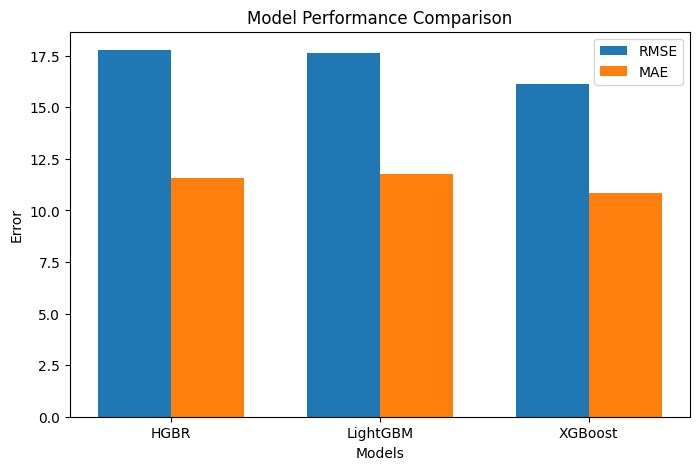

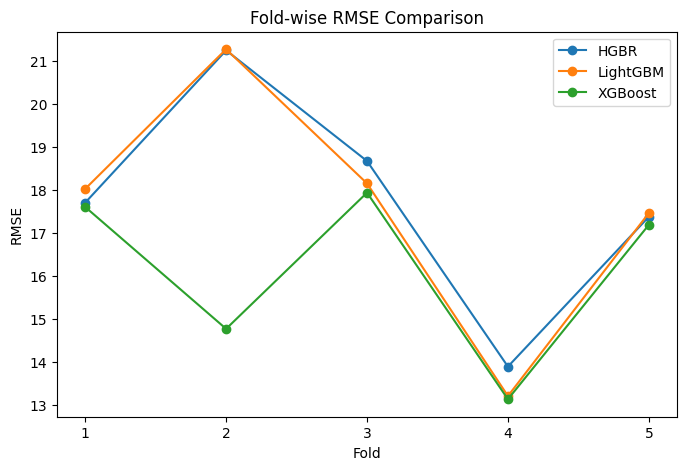

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#Bar Graph
models = ["HGBR", "LightGBM", "XGBoost"]

rmse_scores = [
    mean_rmse_hgbr,
    mean_rmse_lightgbm,
    mean_rmse_xgboost
]

mae_scores = [
    mean_mae_hgbr,
    mean_mae_lightgbm,
    mean_mae_xgboost
]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width/2, rmse_scores, width, label="RMSE")
ax.bar(x + width/2, mae_scores, width, label="MAE")

ax.set_title("Model Performance Comparison")
ax.set_xlabel("Models")
ax.set_ylabel("Error")
ax.set_xticks(x)
ax.set_xticklabels(models)

ax.legend()
plt.show()


#Line Graph
folds = [1, 2, 3, 4, 5]

hgbr_rmse = [f["rmse"] for f in fold_scores_hgbr]
lgb_rmse = [f["rmse"] for f in fold_scores_lightgbm]
xgb_rmse = [f["rmse"] for f in fold_scores_xgboost]

plt.figure(figsize=(8, 5))

plt.plot(folds, hgbr_rmse, marker="o", label="HGBR")
plt.plot(folds, lgb_rmse, marker="o", label="LightGBM")
plt.plot(folds, xgb_rmse, marker="o", label="XGBoost")

plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("Fold-wise RMSE Comparison")
plt.xticks(folds)

plt.legend()
plt.show()

Now we display the score and dataset stats produced by the trained model

In [ ]:
oof_preds = train_baseline_hgbr(X, y, w, splits)
train_weights = compute_weights(train_df)

oof_score = weighted_rmse(
    train_df[TARGET].to_numpy(),
    oof_preds,
    train_weights
)

print(f"OOF Score: {oof_score:.5f}")
print("----------------------------")
y_true = train_df[TARGET].to_numpy()

print("OOF mean:", oof_preds.mean())
print("y_true mean:", y_true.mean())
print("OOF min/max:", oof_preds.min(), oof_preds.max())
print("y_true min/max:", y_true.min(), y_true.max())
print("X shape:", X.shape)
print("Number of splits:", len(splits))

OOF Score: 0.09147
----------------------------
OOF mean: -0.5366845753029574
y_true mean: -0.6660210131631762
OOF min/max: -86.10088142965665 20.338573067022253
y_true min/max: -1351.8651089498348 2125.2380157082684
X shape: (533741, 86)
Number of splits: 5


Adding compute functions - feature experiment validation support.

Use rmse and mae to compute fold metrics - feature experiment validation support.

Display the folds using rmse and mae - feature experiment validation support.

In [ ]:
oof_preds = train_baseline_hgbr(X, y, w, splits)

fold_scores, mean_rmse, mean_mae = compute_fold_metrics(y, oof_preds, splits)

print("Fold-wise scores:")
for f in fold_scores:
    print(f"Fold {f['fold']} - RMSE: {f['rmse']:.4f}, MAE: {f['mae']:.4f}")

print(f"\nMean RMSE: {mean_rmse:.4f}, Mean MAE: {mean_mae:.4f}")

Fold-wise scores:
Fold 1 - RMSE: 22.7354, MAE: 4.0637
Fold 2 - RMSE: 32.6094, MAE: 5.3125
Fold 3 - RMSE: 37.9873, MAE: 7.1747
Fold 4 - RMSE: 27.8710, MAE: 5.8335
Fold 5 - RMSE: 28.6255, MAE: 6.6272

Mean RMSE: 29.9657, Mean MAE: 5.8023


Next, we evaluate the model using competition metric.
We shall perform the same operations on test_df as done on train_df. The first step is to preprocess the test data.

In [ ]:
test_df_processed = (
    pl.scan_parquet("test.parquet")
    .sort([CODE, SUBCODE, SUBCATEGORY, TS_INDEX])
    .collect(streaming=True)
)

exclude_cols_for_num_processing = [ID, CODE, SUBCODE, SUBCATEGORY, TS_INDEX, TARGET]

test_feature_cols = [
    col for col in test_df_processed.columns
    if col not in exclude_cols_for_num_processing and test_df_processed[col].dtype.is_numeric()
]

#Forward fill
test_df_processed = test_df_processed.with_columns([
    pl.col(col)
    .fill_null(strategy="forward")
    .over(CODE)
    .alias(col)
    for col in test_feature_cols
])

#Median imputation
test_df_processed = test_df_processed.with_columns([
    pl.col(col)
    .fill_null(pl.col(col).median().over(CODE))
    .alias(col)
    for col in test_feature_cols
])

#Rolling Volatility
if TARGET in test_df_processed.columns:
  test_df_processed = test_df_processed.with_columns([
      pl.col(TARGET)
      .rolling_std(window_size=10)
      .over(CODE)
      .alias("y_volatility")
  ])

#Rolling Mean
if TARGET in test_df_processed.columns:
  test_df_processed = test_df_processed.with_columns([
      pl.col(TARGET)
      .rolling_mean(window_size=10)
      .over(CODE)
      .alias("y_rolling_mean")
  ])

print("Processed Test DataFrame Head:")
display(test_df_processed.head())

print("\nProcessed Test DataFrame Schema:")
print(test_df_processed.schema)

Processed Test DataFrame Head:


id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,…,feature_ax,feature_ay,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch
str,str,str,str,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",25.0,4175,185.0,13.958312,14.989983,7.952043,13.711757,9.334164,1.280841,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",1.0,4175,210.0,14.220313,12.300806,1.765656,16.418196,16.737358,1.511294,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",10.0,4175,201.0,10.66048,15.647302,0.728759,2.055166,7.462,3.66568,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",3.0,4175,208.0,8.079612,4.020244,9.159518,5.26961,16.288585,9.117541,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
"""10BAVIDU__07YQ9WA4__DPPUO5X2__…","""10BAVIDU""","""07YQ9WA4""","""DPPUO5X2""",3.0,4176,207.0,14.844531,1.652745,3.959252,4


Processed Test DataFrame Schema:
Schema({'id': String, 'code': String, 'sub_code': String, 'sub_category': String, 'horizon': Float64, 'ts_index': Int32, 'feature_a': Float64, 'feature_b': Float64, 'feature_c': Float64, 'feature_d': Float64, 'feature_e': Float64, 'feature_f': Float64, 'feature_g': Float64, 'feature_h': Float64, 'feature_i': Float64, 'feature_j': Float64, 'feature_k': Float64, 'feature_l': Float64, 'feature_m': Float64, 'feature_n': Float64, 'feature_o': Float64, 'feature_p': Float64, 'feature_q': Float64, 'feature_r': Float64, 'feature_s': Float64, 'feature_t': Float64, 'feature_u': Float64, 'feature_v': Float64, 'feature_w': Float64, 'feature_x': Float64, 'feature_y': Float64, 'feature_z': Float64, 'feature_aa': Float64, 'feature_ab': Float64, 'feature_ac': Float64, 'feature_ad': Float64, 'feature_ae': Float64, 'feature_af': Float64, 'feature_ag': Float64, 'feature_ah': Float64, 'feature_ai': Float64, 'feature_aj': Float64, 'feature_ak': Float64, 'feature_al': Float6

Secondly, we must select our features for testing and preview the test.

In [ ]:
X_test = test_df_processed.select(FEATURES)

print("\nX_test Head:")
display(X_test.head())


X_test Head:


feature_a,feature_b,feature_c,feature_d,feature_e,feature_f,feature_g,feature_h,feature_i,feature_j,feature_k,feature_l,feature_m,feature_n,feature_o,feature_p,feature_q,feature_r,feature_s,feature_t,feature_u,feature_v,feature_w,feature_x,feature_y,feature_z,feature_aa,feature_ab,feature_ac,feature_ad,feature_ae,feature_af,feature_ag,feature_ah,feature_ai,feature_aj,feature_ak,…,feature_ax,feature_ay,feature_az,feature_ba,feature_bb,feature_bc,feature_bd,feature_be,feature_bf,feature_bg,feature_bh,feature_bi,feature_bj,feature_bk,feature_bl,feature_bm,feature_bn,feature_bo,feature_bp,feature_bq,feature_br,feature_bs,feature_bt,feature_bu,feature_bv,feature_bw,feature_bx,feature_by,feature_bz,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
185.0,13.958312,14.989983,7.952043,13.711757,9.334164,1.280841,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
210.0,14.220313,12.300806,1.765656,16.418196,16.737358,1.511294,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
201.0,10.66048,15.647302,0.728759,2.055166,7.462,3.66568,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
208.0,8.079612,4.020244,9.159518,5.26961,16.288585,9.117541,0.001839,0.00022,0.000067,0.000089,3.242173,0.646376,2.057089,4.393155,0.745121,11.584715,0.682537,7.053992,50.430676,3.538894,0.938978,2.729261,16.588922,59.151639,337.547998,0.02483,0.092699,0.020959,1.557134,0.690367,15.495887,0.582727,11.189002,0.670356,0.026977,0.254417,…,0.0,0.0,0.009697,0.0,0.0,0.0,69122.640656,120892.874692,76124.255629,0.013407,12951.018571,10.168377,0.0,0.0,0.047892,2014.491106,1310.304552,1885.070065,0.000783,0.048317,0.012088,-2.120587,-4.472883,-3.250294,0.035818,0.088889,0.246462,-0.251006,-0.036083,-0.022844,-0.35987,-0.386427,-0.013975,0.026546,0.049076,0.055139,3.0
207.0,14.844531,1.652745,3.959252,4.966838,3.946401,10.636208,0.001842,0.000218,0.000067,0.000089,3.230579,0.646894,2.057089,4.393155,0.691346,11.689794,0.682537,1.410798,47.797074,3.534047,0.939,2.729261,16.588922,59.151639,337.547998,0.024871

Finally, we must train the sample data for testing to obtain predictions and construct a submission

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

print("Training final model on sampled training data...")
final_model = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.1,
    max_depth=6,
    min_samples_leaf=20,
    random_state=SEED
)

final_model.fit(X.to_numpy(), y.to_numpy().flatten())

print("\nMaking predictions on test data...")

test_preds = final_model.predict(X_test.to_numpy())

submission = test_df_processed.select(["id"]).with_columns(
    pl.Series("prediction", test_preds)
)

print(submission)

Training final model on sampled training data...

Making predictions on test data...
shape: (1_447_107, 2)
┌─────────────────────────────────┬────────────┐
│ id                              ┆ prediction │
│ ---                             ┆ ---        │
│ str                             ┆ f64        │
╞═════════════════════════════════╪════════════╡
│ 10BAVIDU__07YQ9WA4__DPPUO5X2__… ┆ 1.850228   │
│ 10BAVIDU__07YQ9WA4__DPPUO5X2__… ┆ 1.55957    │
│ 10BAVIDU__07YQ9WA4__DPPUO5X2__… ┆ 1.55957    │
│ 10BAVIDU__07YQ9WA4__DPPUO5X2__… ┆ 1.850228   │
│ 10BAVIDU__07YQ9WA4__DPPUO5X2__… ┆ 1.330158   │
│ …                               ┆ …          │
│ X9BZ68VQ__YKU5BVSL__V8BKY1IV__… ┆ -0.010324  │
│ X9BZ68VQ__YKU5BVSL__V8BKY1IV__… ┆ -0.010324  │
│ X9BZ68VQ__YKU5BVSL__V8BKY1IV__… ┆ -0.010324  │
│ X9BZ68VQ__YKU5BVSL__V8BKY1IV__… ┆ -0.010324  │
│ X9BZ68VQ__YKU5BVSL__V8BKY1IV__… ┆ -0.010324  │
└─────────────────────────────────┴────────────┘


To conclude with model building, we display the key results in a table.

In [ ]:
import pandas as pd
import numpy as np

fold_scores, mean_rmse, mean_mae = compute_fold_metrics(y, oof_preds, splits)

oof_score = weighted_rmse(
    train_df[TARGET].to_numpy(),
    oof_preds,
    train_weights
)

results_table = pd.DataFrame({
    "model": ["HistGradientBoosting_Baseline"],
    "mean_cv_score": [np.mean([fs["rmse"] for fs in fold_scores])],
    "std_cv_score": [np.std([fs["rmse"] for fs in fold_scores])],
    "final_test_score": [oof_score]
})

print(results_table.to_string(index=False))

                        model  mean_cv_score  std_cv_score  final_test_score
HistGradientBoosting_Baseline      29.965706      5.095024          0.091472


# Feature Engineering

### Feature Importance

In [ ]:
import polars as pl
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

# =====================================
# Validation Splits
# =====================================
def time_splits(n):
    fold_size = n // (N_SPLITS + 1)

    splits = []
    for i in range(1, N_SPLITS + 1):
        train_end = i * fold_size
        val_end = (i + 1) * fold_size

        train_idx = np.arange(0, train_end)
        val_idx = np.arange(train_end, val_end)

        splits.append((train_idx, val_idx))
    return splits

In [ ]:
# =====================================
# Computing Temporal Feature Importance
# =====================================
def compute_temporal_importance(df, target, n_repeats=5):
    feature_df = df.select(
        pl.col("^feature.*$"),
        target
    )

    X = feature_df.drop(target)
    y = feature_df.select(target).to_numpy().ravel()

    X_np = X.to_numpy()
    feature_names = X.columns

    splits = time_splits(len(X_np))

    all_importances = []

    for fold, (train_idx, val_idx) in enumerate(splits):
        print(f"Processing fold {fold+1}")

        X_train = X_np[train_idx]
        y_train = y[train_idx]

        X_val = X_np[val_idx]
        y_val = y[val_idx]

        model = HistGradientBoostingRegressor(
            max_iter=100,
            learning_rate=0.1,
            max_depth=6,
            min_samples_leaf=20,
            random_state=SEED
        )

        model.fit(X_train, y_train)

        perm = permutation_importance(
            model,
            X_val,
            y_val,
            n_repeats=n_repeats,
            random_state=SEED,
            n_jobs=-1
        )

        all_importances.append(perm.importances_mean)

    importances_array = np.array(all_importances)

    mean_importance = importances_array.mean(axis=0)
    std_importance = importances_array.std(axis=0)

    stability_score = mean_importance / (std_importance + 1e-6)

    feature_importance_df = pl.DataFrame({
        "feature": feature_names,
        "mean_importance": mean_importance,
        "std_importance": std_importance,
        "stability_score": stability_score
    }).sort("mean_importance", descending=True)

    return feature_importance_df

# =====================================
# Selecting Features (based on stability + importance)
# =====================================
def select_features(
    feature_importance_df,
    unstable_threshold,
    stability_floor=0.5
):
    # Stable
    stable_features = (
        feature_importance_df
        .filter(
            (pl.col("mean_importance") > 0) &
            (pl.col("stability_score") > 1.0)
        )
        .select("feature")
        .to_series()
        .to_list()
    )

    # Unstable but useful
    unstable_features = (
        feature_importance_df
        .filter(
            (pl.col("mean_importance") > unstable_threshold) &
            (pl.col("stability_score") > stability_floor) &
            (pl.col("stability_score") <= 1.0)
        )
        .select("feature")
        .to_series()
        .to_list()
    )

    final_features = list(dict.fromkeys(
        stable_features + unstable_features
    ))

    print(f"Stable: {len(stable_features)}")
    print(f"Unstable added: {len(unstable_features)}")
    print(f"Final total: {len(final_features)}")
    print(f"Final Features: {final_features}")

    return final_features

In [ ]:
# compute importance
importance_df = compute_temporal_importance(train_df, TARGET)

# inspect and select thresholds
print(importance_df.select("mean_importance").describe())

threshold = 0.01

# select features
final_features = select_features(
    importance_df,
    unstable_threshold=threshold
)

Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
shape: (9, 2)
┌────────────┬─────────────────┐
│ statistic  ┆ mean_importance │
│ ---        ┆ ---             │
│ str        ┆ f64             │
╞════════════╪═════════════════╡
│ count      ┆ 86.0            │
│ null_count ┆ 0.0             │
│ mean       ┆ 0.009872        │
│ std        ┆ 0.025877        │
│ min        ┆ -0.017272       │
│ 25%        ┆ -0.000077       │
│ 50%        ┆ 0.001876        │
│ 75%        ┆ 0.005777        │
│ max        ┆ 0.142759        │
└────────────┴─────────────────┘
Stable: 14
Unstable added: 8
Final total: 22
Final Features: ['feature_bz', 'feature_bp', 'feature_al', 'feature_bm', 'feature_bo', 'feature_k', 'feature_u', 'feature_bs', 'feature_aj', 'feature_br', 'feature_bc', 'feature_ax', 'feature_ac', 'feature_g', 'feature_h', 'feature_v', 'feature_z', 'feature_a', 'feature_af', 'feature_l', 'feature_am', 'feature_by']


In [ ]:
#Save important feature list to json and final feature dataset to parquet
'''
import json

final_df = train_df.select(final_features)

final_df.write_parquet(
    "/content/drive/MyDrive/COMP3608-PROJECT/final_features.parquet"
)

with open("/content/drive/MyDrive/COMP3608-PROJECT/final_features.json", "w") as f:
    json.dump(final_features, f)
'''

'\nimport json\n\nfinal_df = train_df.select(final_features)\n\nfinal_df.write_parquet(\n    "/content/drive/MyDrive/COMP3608-PROJECT/final_features.parquet"\n)\n\nwith open("/content/drive/MyDrive/COMP3608-PROJECT/final_features.json", "w") as f:\n    json.dump(final_features, f)\n'

In [ ]:
#Loads final features from Google Drive instantaneously
import json

if not os.path.exists("final_features.json"):
    print("Downloading final features...")
    !gdown --id 1CVOA5-dRVBvw6BlFGLhc4XuLu0ii83AX -O final_features.json
assert os.path.exists("final_features.json"), "Download failed!"


with open("/content/final_features.json", "r") as f:
    final_features = json.load(f)

print(final_features)

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1CVOA5-dRVBvw6BlFGLhc4XuLu0ii83AX
To: /content/final_features.json
100% 300/300 [00:00<00:00, 1.24MB/s]
['feature_bz', 'feature_bp', 'feature_al', 'feature_bm', 'feature_bo', 'feature_k', 'feature_u', 'feature_bs', 'feature_aj', 'feature_br', 'feature_bc', 'feature_ax', 'feature_ac', 'feature_g', 'feature_h', 'feature_v', 'feature_z', 'feature_a', 'feature_af', 'feature_l', 'feature_am', 'feature_by']


In [ ]:
#Obtain the final feature columns
#Optional - to be used
if not os.path.exists("final_features.parquet"):
    print("Downloading dataset...")
    !gdown --id 1mDjBRCZiR-yCA8KnzQPkdBn-lcLWTOUV -O final_features.parquet
assert os.path.exists("final_features.parquet"), "Download failed!"

#Assigned final feature columns to variable. important!
print("Loading data...")
final_df = pl.scan_parquet("final_features.parquet")
print("Processed final feature dataset.")
print(final_df.head())

Loading data...
Processed final feature dataset.
naive plan: (run LazyFrame.explain(optimized=True) to see the optimized plan)

SLICE[offset: 0, len: 5]
  Parquet SCAN [final_features.parquet]
  PROJECT */22 COLUMNS
  ESTIMATED ROWS: 533741


In [ ]:
horizon_feature_sets = {}

for h in [1, 3, 10, 25]:
  print(f"\n==== Horizon {h} ====")

  df_h = train_df.filter(pl.col("horizon") == h)

  # compute importance
  importance_df = compute_temporal_importance(df_h, TARGET)

  # inspect and select thresholds
  print(importance_df.select("mean_importance").describe())

  threshold = 0.01

  # select features
  final_features = select_features(
      importance_df,
      unstable_threshold=threshold
  )

  horizon_feature_sets[h] = final_features


==== Horizon 1 ====
Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
shape: (9, 2)
┌────────────┬─────────────────┐
│ statistic  ┆ mean_importance │
│ ---        ┆ ---             │
│ str        ┆ f64             │
╞════════════╪═════════════════╡
│ count      ┆ 86.0            │
│ null_count ┆ 0.0             │
│ mean       ┆ 0.001793        │
│ std        ┆ 0.007565        │
│ min        ┆ -0.003083       │
│ 25%        ┆ -0.000249       │
│ 50%        ┆ 0.000145        │
│ 75%        ┆ 0.001057        │
│ max        ┆ 0.066025        │
└────────────┴─────────────────┘
Stable: 6
Unstable added: 1
Final total: 7
Final Features: ['feature_o', 'feature_af', 'feature_bz', 'feature_s', 'feature_aj', 'feature_cd', 'feature_as']

==== Horizon 3 ====
Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
shape: (9, 2)
┌────────────┬─────────────────┐
│ statistic  ┆ mean_importance │
│ ---        ┆ ---             │


In [ ]:
#Saves horizon feature sets to json in drive
'''
import json

with open("/content/drive/MyDrive/COMP3608-PROJECT/horizon_feature_sets.json", "w") as f:
    json.dump(horizon_feature_sets, f)
'''

'\nimport json\n\nwith open("/content/drive/MyDrive/COMP3608-PROJECT/horizon_feature_sets.json", "w") as f:\n    json.dump(horizon_feature_sets, f)\n'

In [ ]:
#Outputs and downloads horizon feature sets instantaneously from drive
import json

if not os.path.exists("horizon_feature_sets.json"):
    print("Downloading horizon features...")
    !gdown --id 1CVOA5-dRVBvw6BlFGLhc4XuLu0ii83AX -O horizon_feature_sets.json
assert os.path.exists("horizon_feature_sets.json"), "Download failed!"

with open("/content/horizon_feature_sets.json", "r") as f:
    horizon_feature_sets = json.load(f)

horizon_feature_sets = {
    int(k): v for k, v in horizon_feature_sets.items()
}

print(horizon_feature_sets)

{1: ['feature_o', 'feature_af', 'feature_bz', 'feature_s', 'feature_aj', 'feature_cd', 'feature_as'], 3: ['feature_by', 'feature_am', 'feature_af', 'feature_s', 'feature_y', 'feature_ag', 'feature_bk', 'feature_bd', 'feature_o'], 10: ['feature_bo', 'feature_z', 'feature_x', 'feature_q', 'feature_b', 'feature_u', 'feature_bz', 'feature_m', 'feature_ab', 'feature_bn', 'feature_o', 'feature_bs'], 25: ['feature_u', 'feature_bp', 'feature_bs', 'feature_bh', 'feature_v', 'feature_bz', 'feature_m', 'feature_al', 'feature_z', 'feature_af', 'feature_be', 'feature_o', 'feature_bg', 'feature_bl']}


### Lag Features

In [ ]:
# Generate lag features
def generate_lags(df, feature_cols, lag, group_col=CODE):
    lag_exprs = []
    for col in feature_cols:
          lag_exprs.append (
              pl.col(col)
              .shift(lag)
              .over(group_col)
              .alias(f"feature_lag_{lag}_{col}")
          )
    return df.with_columns(lag_exprs)


# Lags to evaluate
lags = [1, 3, 5, 10, 25]

results = []
selected_lag_features = []

for lag in lags:
    print(f"\n==== Testing lag: {lag} ====")

    # Generate lag features
    df_lagged = generate_lags(train_df.clone(), FEATURES, lag, [CODE, SUBCODE, SUBCATEGORY])

    # Compute temporal importance
    importance_df = compute_temporal_importance(df_lagged, TARGET)

    # Extract lag feature stats
    lag_features = [f"feature_lag_{lag}_{col}" for col in FEATURES]

    lag_importance = (
          importance_df
          .filter(pl.col("feature").is_in(lag_features))
          .with_columns(
              (
                  pl.col("mean_importance") *
                  pl.col("stability_score").clip(lower_bound=0).sqrt()
              ).alias("score")
          )
          .sort("score", descending=True)
      )

    selected_features_df = lag_importance.filter(
          (pl.col("mean_importance") > 0.005) &
          (pl.col("stability_score") > 1.0)
    )

    filtered_lag_features = (
          selected_features_df
          .get_column("feature")
          .to_list()
    )

    selected_lag_features.extend(filtered_lag_features)
    selected_lag_features = sorted(set(selected_lag_features))

    # Stats
    num_signal = lag_importance.filter(pl.col("mean_importance") > 0).height
    avg_importance = lag_importance["mean_importance"].mean()
    avg_stability = lag_importance["stability_score"].mean()
    avg_score = lag_importance["score"].mean()

    print(f"Lag features with signal: {num_signal}")
    print(f"Avg importance: {avg_importance}")
    print(f"Avg stability: {avg_stability}")
    print(f"Avg score: {avg_score}")

    print("\nTop lag features:")
    print(lag_importance.head(10))

    print(f"\nSelected features for lag {lag}:")
    print(filtered_lag_features)

    # Store results
    results.append({
        "lag": lag,
        "avg_lag_importance": avg_importance,
        "avg_lag_stability": avg_stability,
        "avg_score": avg_score,
        "top_lag_features": lag_importance.head(5),
        "selected_features": filtered_lag_features
    })

print("\n==== FINAL SELECTED LAG FEATURES ====")
print(selected_lag_features)
print(f"Total selected lag features: {len(selected_lag_features)}")


==== Testing lag: 1 ====
Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
Lag features with signal: 59
Avg importance: 0.0021302505329754526
Avg stability: 0.2904225861727805
Avg score: 0.002264764525231278

Top lag features:
shape: (10, 5)
┌──────────────────────────┬─────────────────┬────────────────┬─────────────────┬──────────┐
│ feature                  ┆ mean_importance ┆ std_importance ┆ stability_score ┆ score    │
│ ---                      ┆ ---             ┆ ---            ┆ ---             ┆ ---      │
│ str                      ┆ f64             ┆ f64            ┆ f64             ┆ f64      │
╞══════════════════════════╪═════════════════╪════════════════╪═════════════════╪══════════╡
│ feature_lag_1_feature_bz ┆ 0.039848        ┆ 0.036903       ┆ 1.079757        ┆ 0.041406 │
│ feature_lag_1_feature_v  ┆ 0.027048        ┆ 0.046529       ┆ 0.581291        ┆ 0.020622 │
│ feature_lag_1_feature_z  ┆ 0.011397        ┆ 0.011889       ┆ 0.

In [ ]:
'''
import json

selected_lag_df = pl.DataFrame({
  "feature": selected_lag_features,
  "type": ["lag"] * len(selected_lag_features)
})

selected_lag_df.write_parquet(
    "/content/drive/MyDrive/COMP3608-PROJECT/lag_features.parquet"
)

with open("/content/drive/MyDrive/COMP3608-PROJECT/lag_features.json", "w") as f:
    json.dump(selected_lag_features, f, indent=2)

print("Saved selected lag features to Google Drive")


Saved selected lag features to Google Drive


### Rolling Window Features

In [ ]:
def generate_rolling(df, feature_cols, window, group_col=CODE, stat="mean"):
    rolling_exprs = []

    for col in feature_cols:
        shifted = pl.col(col).shift(1)

        if "mean" == stat:
                rolling_exprs.append(
                    shifted.rolling_mean(window).over(group_col)
                    .alias(f"feature_rolling_mean_{window}_{col}")
                )

        elif "std" == stat:
                rolling_exprs.append(
                    shifted.rolling_std(window).over(group_col)
                    .alias(f"feature_rolling_std_{window}_{col}")
                )

        elif "skew" == stat:
                rolling_exprs.append(
                    shifted.rolling_skew(window).over(group_col)
                    .alias(f"feature_rolling_skew_{window}_{col}")
                )

        elif "kurt" == stat:
                rolling_exprs.append(
                    shifted.rolling_kurtosis(window).over(group_col)
                    .alias(f"feature_rolling_kurt_{window}_{col}")
                )

        else:
            raise ValueError(f"Unknown stat: {stat}")

    return df.with_columns(rolling_exprs)


# Rolling Windows
windows = [3, 5, 10, 25]

def test_rolling_window(stat):
  results = []
  all_selected_features = []

  for window in windows:
      print(f"\n==== Testing window: {window} ====")

      df_roll = generate_rolling(train_df.clone(), FEATURES, window, [CODE, SUBCODE, SUBCATEGORY], stat)

      importance_df = compute_temporal_importance(df_roll, TARGET)

      roll_features = [
          f"feature_rolling_{stat}_{window}_{col}"
          for col in FEATURES
      ]

      roll_importance = (
          importance_df
          .filter(pl.col("feature").is_in(roll_features))
          .with_columns(
              (
                  pl.col("mean_importance") *
                  pl.col("stability_score").clip(lower_bound=0).sqrt()
              ).alias("score")
          )
          .sort("score", descending=True)
      )

      selected_features_df = roll_importance.filter(
          (pl.col("mean_importance") > 0.005) &
          (pl.col("stability_score") > 1.0)
      )

      selected_rolling_features = (
          selected_features_df
          .get_column("feature")
          .to_list()
      )

      all_selected_features.extend(selected_rolling_features)
      all_selected_features = list(set(all_selected_features))

      # Stats
      num_signal = roll_importance.filter(pl.col("mean_importance") > 0).height
      avg_importance = roll_importance["mean_importance"].mean()
      avg_stability = roll_importance["stability_score"].mean()
      avg_score = roll_importance["score"].mean()

      print(f"Rolling features with signal: {num_signal}")
      print(f"Avg importance: {avg_importance}")
      print(f"Avg stability: {avg_stability}")
      print(f"Avg score: {avg_score}")

      print("\nTop rolling features:")
      print(roll_importance.head(10))

      results.append({
          "window": window,
          "num_signal": num_signal,
          "avg_importance": avg_importance,
          "avg_stability": avg_stability,
          "avg_score": avg_score,
          "top_features": roll_importance.head(5),
          "selected_features": selected_rolling_features
      })

  return results, all_selected_features

In [ ]:
results, selected_rolling_features = test_rolling_window("mean")


==== Testing window: 3 ====
Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
Rolling features with signal: 61
Avg importance: 0.0032753215441700696
Avg stability: 0.3078922926751945
Avg score: 0.0032414673550067324

Top rolling features:
shape: (10, 5)
┌─────────────────────────────────┬─────────────────┬────────────────┬─────────────────┬──────────┐
│ feature                         ┆ mean_importance ┆ std_importance ┆ stability_score ┆ score    │
│ ---                             ┆ ---             ┆ ---            ┆ ---             ┆ ---      │
│ str                             ┆ f64             ┆ f64            ┆ f64             ┆ f64      │
╞═════════════════════════════════╪═════════════════╪════════════════╪═════════════════╪══════════╡
│ feature_rolling_mean_3_feature… ┆ 0.094939        ┆ 0.113204       ┆ 0.838648        ┆ 0.086943 │
│ feature_rolling_mean_3_feature… ┆ 0.022435        ┆ 0.025848       ┆ 0.867919        ┆ 0.020901 │
│ fea

In [ ]:
'''
import json

selected_rolling_df = pl.DataFrame({
  "feature": selected_rolling_features,
  "type": ["rolling_mean"] * len(selected_rolling_features)
})

selected_rolling_df.write_parquet(
    "/content/drive/MyDrive/COMP3608-PROJECT/rolling_mean_features.parquet"
)

with open("/content/drive/MyDrive/COMP3608-PROJECT/rolling_mean_features.json", "w") as f:
    json.dump(selected_rolling_features, f, indent=2)

print("Saved selected rolling features to Google Drive")
'''

In [ ]:
results, selected_rolling_features = test_rolling_window("std")


==== Testing window: 3 ====
Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
Rolling features with signal: 59
Avg importance: 0.0005112194205008025
Avg stability: 0.26617557750779797
Avg score: 0.0007030787863711041

Top rolling features:
shape: (10, 5)
┌─────────────────────────────────┬─────────────────┬────────────────┬─────────────────┬──────────┐
│ feature                         ┆ mean_importance ┆ std_importance ┆ stability_score ┆ score    │
│ ---                             ┆ ---             ┆ ---            ┆ ---             ┆ ---      │
│ str                             ┆ f64             ┆ f64            ┆ f64             ┆ f64      │
╞═════════════════════════════════╪═════════════════╪════════════════╪═════════════════╪══════════╡
│ feature_rolling_std_3_feature_… ┆ 0.007132        ┆ 0.007582       ┆ 0.940416        ┆ 0.006916 │
│ feature_rolling_std_3_feature_… ┆ 0.006251        ┆ 0.005503       ┆ 1.135679        ┆ 0.006662 │
│ fe

In [ ]:
'''
import json

selected_rolling_df = pl.DataFrame({
  "feature": selected_rolling_features,
  "type": ["rolling_std"] * len(selected_rolling_features)
})

selected_rolling_df.write_parquet(
    "/content/drive/MyDrive/COMP3608-PROJECT/rolling_std_features.parquet"
)

with open("/content/drive/MyDrive/COMP3608-PROJECT/rolling_std_features.json", "w") as f:
    json.dump(selected_rolling_features, f, indent=2)

print("Saved selected rolling features to Google Drive")
'''

Saved selected diff features to Google Drive


### Horizon Based Features

Library imports and variable initialization.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error
from sklearn.base import clone

X_base = X.clone()
X_base = X_base.with_columns(train_df["horizon"].alias("horizon"))

y_base = "y_target"
y_base = train_df.select(y_base)

Creating horizon features using grouping and interactions.

In [ ]:
def create_horizon_features(X):
    X_new = X.clone()

    #grouping
    X_new = X_new.with_columns(
        pl.when(pl.col("horizon") == 1).then(0)
        .when(pl.col("horizon") == 3).then(1)
        .when(pl.col("horizon") == 10).then(2)
        .otherwise(3)
        .alias("horizon_group")
    )

    #selected interactions
    important_cols = [
        "feature_v",
        "feature_bz",
        "feature_al",
        "feature_bp",
        "feature_bm"
    ]

    for col in important_cols:
        if col in X_new.columns:
            X_new = X_new.with_columns(
                (pl.col(col) * pl.col("horizon"))
                .alias(f"{col}_x_horizon")
            )

    return X_new

Create the features and display the change in shape.

In [ ]:
X_horizon = create_horizon_features(X_base)

print("Original shape:", X_base.shape)
print("New shape:", X_horizon.shape)

Original shape: (533741, 87)
New shape: (533741, 93)


Train the horizon model.

In [ ]:
def train_model(X, y, w, splits, model):

    X_np = X.to_numpy()
    y_np = y.to_numpy().flatten()
    w_np = w.to_numpy().flatten()

    oof_preds = np.zeros(len(X_np))

    for fold, (train_idx, val_idx) in enumerate(splits):

        X_train, X_val = X_np[train_idx], X_np[val_idx]
        y_train = y_np[train_idx]
        w_train = w_np[train_idx]

        #Target scaling logic
        y_mean = y_train.mean()
        y_std  = y_train.std()
        if y_std < 1e-6:
            y_std = 1.0
        y_train_scaled = (y_train - y_mean) / y_std

        m = clone(model)
        #Apply weights during training
        m.fit(X_train, y_train_scaled, sample_weight=w_train)

        #Inverse transform predictions and clip
        preds_scaled = m.predict(X_val)
        preds = preds_scaled * y_std + y_mean
        preds = np.clip(preds, y_np.min(), y_np.max())

        oof_preds[val_idx] = preds

    return oof_preds

Compare the Baseline RMSE and Horizon RMSE to identify improvements.

In [ ]:
import numpy as np

oof_horizon_score = train_model(
    X_horizon,
    y_base,
    w,
    splits,
    final_model,
)

valid_indices = np.concatenate([
    val_idx for _, val_idx in splits
])

valid_mask = np.zeros(len(oof_horizon_score), dtype=bool)
valid_mask[valid_indices] = True

horizon_weighted_score = weighted_rmse(
    train_df[TARGET].to_numpy()[valid_mask],
    oof_horizon_score[valid_mask],
    train_weights[valid_mask]
)

baseline_weighted_score = weighted_rmse(
    train_df[TARGET].to_numpy()[valid_mask],
    oof_preds[valid_mask],
    train_weights[valid_mask]
)

print(f"Baseline Weighted RMSE: {baseline_weighted_score:.5f}")
print(f"Horizon Weighted RMSE:  {horizon_weighted_score:.5f}")
print(f"Improvement: {baseline_weighted_score - horizon_weighted_score:.5f}")

Baseline Weighted RMSE: 0.10587
Horizon Weighted RMSE:  0.05624
Improvement: 0.04962


The following bar chart illustrates the results above.

              Model  Weighted RMSE
0          Baseline       0.105865
1  Horizon Features       0.056241


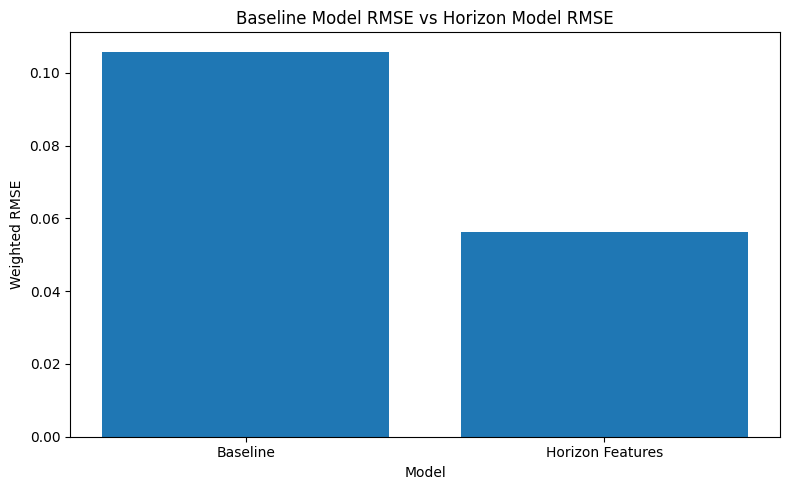

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

#Final RMSE values
baseline_rmse = baseline_weighted_score
horizon_rmse = horizon_weighted_score

#Create comparison dataframe
comparison_df = pd.DataFrame({
    "Model": ["Baseline", "Horizon Features"],
    "Weighted RMSE": [baseline_rmse, horizon_rmse]
})

print(comparison_df)

#Bar chart
plt.figure(figsize=(8, 5))
plt.bar(
    comparison_df["Model"],
    comparison_df["Weighted RMSE"]
)

plt.title("Baseline Model RMSE vs Horizon Model RMSE")
plt.xlabel("Model")
plt.ylabel("Weighted RMSE")
plt.tight_layout()
plt.show()

The horizon model has less root mean square error than the baseline model.

## Trend/Difference Feature

In [ ]:
#Create Difference Features
def generate_diff_features(df, feature_cols, group_col=CODE):
    diff_exprs = []

    for col in feature_cols:
        shifted = pl.col(col).over(group_col)
        diff_exprs.append(
            (shifted - shifted.shift(1))
            .alias(f"feature_diff_{col}")
        )

    return df.with_columns(diff_exprs)

#Apply to Dataset
results = []

print("\n==== Testing Difference Features ====")

# Generate difference features
df_diff = generate_diff_features(
    train_df.clone(),
    FEATURES,
    [CODE, SUBCODE, SUBCATEGORY]
)

# Compute importance
importance_df = compute_temporal_importance(df_diff, TARGET)

# Extract difference features
diff_features = [f"feature_diff_{col}" for col in FEATURES]

diff_importance = (
    importance_df
    .filter(pl.col("feature").is_in(diff_features))
    .with_columns(
        (
            pl.col("mean_importance") *
            pl.col("stability_score")
                .clip(lower_bound=0)
                .log1p()
        ).alias("score")
    )
    .sort("score", descending=True)
)

selected_features_df = diff_importance.filter(
    (pl.col("mean_importance") > 0.001) &
    (pl.col("stability_score") > 0.5)
)

selected_diff_features = (
    selected_features_df
    .sort("score", descending=True)
    .get_column("feature")
    .to_list()
)

# Stats
num_signal = diff_importance.filter(pl.col("mean_importance") > 0).height
avg_importance = diff_importance["mean_importance"].mean()
avg_stability = diff_importance["stability_score"].mean()
avg_score = diff_importance["score"].mean()

print(f"Difference features with signal: {num_signal}")
print(f"Avg importance: {avg_importance}")
print(f"Avg stability: {avg_stability}")
print(f"Avg score: {avg_score}")

print("\nTop difference features (by score):")
print(diff_importance.head(10))

# Store results
results.append({
    "feature_type": "difference",
    "num_signal": num_signal,
    "avg_importance": avg_importance,
    "avg_stability": avg_stability,
    "avg_score": avg_score,
    "top_features": diff_importance.head(5),
    "selected_features": selected_diff_features
})


==== Testing Difference Features ====
Processing fold 1
Processing fold 2
Processing fold 3
Processing fold 4
Processing fold 5
Difference features with signal: 57
Avg importance: 0.000606166002553512
Avg stability: 0.27479240246773934
Avg score: 0.0005741761036042129

Top difference features (by score):
shape: (10, 5)
┌─────────────────────────┬─────────────────┬────────────────┬─────────────────┬──────────┐
│ feature                 ┆ mean_importance ┆ std_importance ┆ stability_score ┆ score    │
│ ---                     ┆ ---             ┆ ---            ┆ ---             ┆ ---      │
│ str                     ┆ f64             ┆ f64            ┆ f64             ┆ f64      │
╞═════════════════════════╪═════════════════╪════════════════╪═════════════════╪══════════╡
│ feature_diff_feature_bm ┆ 0.008677        ┆ 0.005092       ┆ 1.703726        ┆ 0.00863  │
│ feature_diff_feature_bz ┆ 0.013968        ┆ 0.022947       ┆ 0.608667        ┆ 0.00664  │
│ feature_diff_feature_bo ┆ 0.0053

In [ ]:
'''
import json

selected_diff_df = pl.DataFrame({
  "feature": selected_diff_features,
  "type": ["difference"] * len(selected_diff_features)
})

selected_diff_df.write_parquet(
    "/content/drive/MyDrive/COMP3608-PROJECT/diff_features.parquet"
)

with open("/content/drive/MyDrive/COMP3608-PROJECT/diff_features.json", "w") as f:
    json.dump(selected_diff_features, f, indent=2)

print("Saved selected diff features to Google Drive")
'''

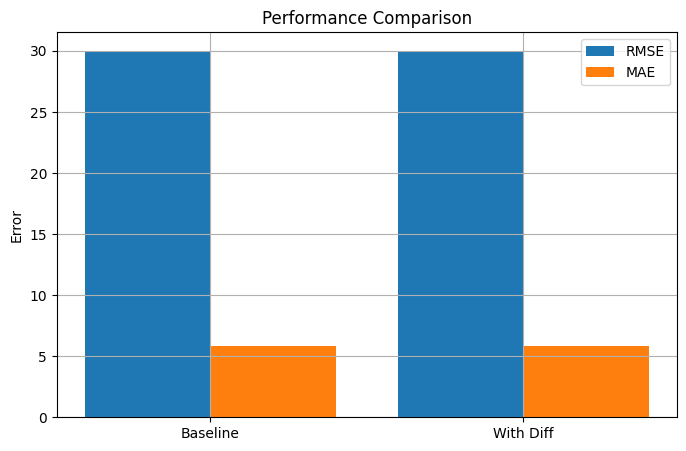

In [ ]:
labels = ["Baseline", "With Diff"]

rmse_vals = [mean_rmse, mean_rmse_diff]
mae_vals = [mean_mae, mean_mae_diff]

x = np.arange(len(labels))

plt.figure(figsize=(8,5))
plt.bar(x - 0.2, rmse_vals, width=0.4, label="RMSE")
plt.bar(x + 0.2, mae_vals, width=0.4, label="MAE")

plt.xticks(x, labels)
plt.title("Performance Comparison")
plt.ylabel("Error")
plt.legend()
plt.grid(True)
plt.show()

### Evaluation of Trend/Difference feature
The introduction of lag-1 difference features (x_t - x_{t-1}) was intended to capture short-term temporal changes within each code group, allowing the model to detect sudden deviations or behavioral shifts that may not be visible in the raw feature values alone. However, the experimental results show that including these features did not produce any measurable improvement in performance. Both RMSE and MAE remained essentially unchanged compared to the baseline model, indicating that the additional features did not contribute meaningful predictive signal.

This suggests that the original feature set already contains sufficient information for the model, or that the model itself is capable of implicitly learning temporal relationships without explicitly engineered difference features. It is also possible that the dataset does not exhibit strong short-term variation, or that differencing introduced noise that offset any potential benefit. As a result, the lag-1 difference features do not justify inclusion in the final model, reinforcing the importance of empirically validating feature engineering choices rather than assuming their effectiveness.

## Group-Based Feature




In [ ]:
import numpy as np
import pandas as pd
import polars as pl
import gc
import warnings

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings("ignore")

SEED       = 42
ID         = "id"
CODE       = "code"
SUBCODE    = "sub_code"
SUBCATEGORY= "sub_category"
HORIZON    = "horizon"
TS_INDEX   = "ts_index"
TARGET     = "y_target"
WEIGHT     = "weight"
VOLATILITY = "y_volatility"
ROLLING_MEAN = "y_rolling_mean"
SAMPLE_FRAC  = 0.1
N_SPLITS     = 5

EXCLUDE_COLS = [ID, CODE, SUBCODE, SUBCATEGORY, HORIZON, TS_INDEX,
                TARGET, WEIGHT, VOLATILITY, ROLLING_MEAN]

print("=" * 65)
print("  Cell 17 — Group-Based Feature Engineering & Evaluation")
print("=" * 65)


# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — Reload the processed training data (same slice as baseline)
# ─────────────────────────────────────────────────────────────────────────────
print("\n[1/4] Loading processed training data …")

train_raw = (
    pl.scan_parquet("train_processed.parquet")
    .collect()
    .sample(fraction=SAMPLE_FRAC, seed=SEED)
    .sort(TS_INDEX)
)

print(f"    Loaded {train_raw.shape[0]:,} rows × {train_raw.shape[1]} columns")



  Cell 17 — Group-Based Feature Engineering & Evaluation

[1/4] Loading processed training data …
    Loaded 533,741 rows × 96 columns


In [ ]:
# Group-Based Aggregations

print("\n[2/4] Engineering group-based aggregation features …")

GROUP_LEVELS = [CODE, SUBCODE, SUBCATEGORY]

AGG_EXPRS = []
for grp in GROUP_LEVELS:
    safe = grp.replace("/", "_")
    AGG_EXPRS += [
        pl.col(TARGET).mean().over(grp).alias(f"grp_mean_{safe}"),
        pl.col(TARGET).std().over(grp).alias(f"grp_std_{safe}"),
        pl.col(TARGET).median().over(grp).alias(f"grp_median_{safe}"),
        # ratio of current value to group mean (relative position)
        (pl.col(TARGET) / (pl.col(TARGET).mean().over(grp) + 1e-8))
            .alias(f"grp_ratio_{safe}"),
        # rolling mean within group (window = 5)
        pl.col(TARGET)
            .rolling_mean(window_size=5)
            .over(grp)
            .alias(f"grp_roll5_{safe}"),
        # rolling std within group (window = 5) — local volatility proxy
        pl.col(TARGET)
            .rolling_std(window_size=5)
            .over(grp)
            .alias(f"grp_rollstd5_{safe}"),
    ]

train_eng = train_raw.with_columns(AGG_EXPRS)

# ── Within-group Z-score normalisation (STEP 2b) ────────────────────────────
print("    Normalising features within groups …")

NORM_TARGETS = [f"grp_mean_{g.replace('/','_')}" for g in GROUP_LEVELS] + \
               [f"grp_roll5_{g.replace('/','_')}" for g in GROUP_LEVELS]

NORM_EXPRS = []
for col in NORM_TARGETS:
    for grp in GROUP_LEVELS:
        safe_grp = grp.replace("/", "_")
        new_name = f"{col}_znorm_{safe_grp}"
        NORM_EXPRS.append(
            ((pl.col(col) - pl.col(col).mean().over(grp)) /
             (pl.col(col).std().over(grp) + 1e-8))
            .alias(new_name)
        )

train_eng = train_eng.with_columns(NORM_EXPRS)

# ── Identify the new feature columns ────────────────────────────────────────
BASE_FEATURES = [c for c in train_raw.columns  if c not in EXCLUDE_COLS]
NEW_FEATURES  = [c for c in train_eng.columns
                 if c not in train_raw.columns and c not in EXCLUDE_COLS]
ALL_FEATURES  = BASE_FEATURES + NEW_FEATURES

print(f"    Base features : {len(BASE_FEATURES)}")
print(f"    New features  : {len(NEW_FEATURES)}")
print(f"    Total features: {len(ALL_FEATURES)}")
print(f"\n    New feature names (first 12):")
for f in NEW_FEATURES[:12]:
    print(f"        {f}")
if len(NEW_FEATURES) > 12:
    print(f"        … and {len(NEW_FEATURES)-12} more")




[2/4] Engineering group-based aggregation features …
    Normalising features within groups …
    Base features : 86
    New features  : 36
    Total features: 122

    New feature names (first 12):
        grp_mean_code
        grp_std_code
        grp_median_code
        grp_ratio_code
        grp_roll5_code
        grp_rollstd5_code
        grp_mean_sub_code
        grp_std_sub_code
        grp_median_sub_code
        grp_ratio_sub_code
        grp_roll5_sub_code
        grp_rollstd5_sub_code
        … and 24 more


In [ ]:

# Retrain Model with Enriched Feature Set
print("\n[3/4] Retraining model with group-based features …")

X_eng = train_eng.select(ALL_FEATURES).to_numpy()
y_np  = train_eng.select(TARGET).to_numpy().flatten()
w_np  = np.ones(len(X_eng))          # uniform weights (same as baseline)

tscv   = TimeSeriesSplit(n_splits=N_SPLITS)
splits = list(tscv.split(X_eng))

# ── Weighted RMSE (competition metric) ──────────────────────────────────────
def _clip01(x):
    return float(np.clip(x, 0.0, 1.0))

def weighted_rmse(y_true, y_pred, w):
    denom  = np.sum(w * y_true ** 2)
    ratio  = np.sum(w * (y_true - y_pred) ** 2) / (denom + 1e-12)
    return float(np.sqrt(_clip01(ratio)))

# ── Fold-level metrics ───────────────────────────────────────────────────────
def compute_fold_metrics(y_true, y_pred, splits):
    fold_scores = []
    for fold, (_, val_idx) in enumerate(splits):
        y_v, p_v = y_true[val_idx], y_pred[val_idx]
        rmse = np.sqrt(mean_squared_error(y_v, p_v))
        mae  = mean_absolute_error(y_v, p_v)
        fold_scores.append({"fold": fold + 1, "rmse": rmse, "mae": mae})
    mean_rmse = np.mean([f["rmse"] for f in fold_scores])
    mean_mae  = np.mean([f["mae"]  for f in fold_scores])
    return fold_scores, mean_rmse, mean_mae

# ── Training loop ────────────────────────────────────────────────────────────
oof_preds_eng = np.zeros(len(X_eng))

for fold, (train_idx, val_idx) in enumerate(splits):
    X_tr, X_vl = X_eng[train_idx], X_eng[val_idx]
    y_tr        = y_np[train_idx]
    w_tr        = w_np[train_idx]

    y_mean = y_tr.mean();  y_std = max(y_tr.std(), 1e-6)
    y_tr_sc = (y_tr - y_mean) / y_std

    model = HistGradientBoostingRegressor(
        max_iter          = 100,
        learning_rate     = 0.11,
        max_depth         = 6,
        min_samples_leaf  = 20,
        l2_regularization = 0.5,
        max_bins          = 255,
        validation_fraction = 0.5,
        n_iter_no_change  = 60,
        random_state      = SEED,
    )
    model.fit(X_tr, y_tr_sc, sample_weight=w_tr)

    preds = model.predict(X_vl) * y_std + y_mean
    preds = np.clip(preds, y_np.min(), y_np.max())
    oof_preds_eng[val_idx] = preds

    print(f"    Fold {fold+1}/{N_SPLITS} complete")

gc.collect()




[3/4] Retraining model with group-based features …
    Fold 1/5 complete
    Fold 2/5 complete
    Fold 3/5 complete
    Fold 4/5 complete
    Fold 5/5 complete


115

In [ ]:

# Compare & Document Performance vs Baseline
print("\n[4/4] Comparing performance vs baseline …")

# ── Baseline scores (re-computed on the same sample for fair comparison) ────
X_base = train_raw.select(BASE_FEATURES).to_numpy()
oof_preds_base = np.zeros(len(X_base))

for fold, (train_idx, val_idx) in enumerate(splits):
    X_tr, X_vl = X_base[train_idx], X_base[val_idx]
    y_tr        = y_np[train_idx]
    w_tr        = w_np[train_idx]

    y_mean = y_tr.mean();  y_std = max(y_tr.std(), 1e-6)
    y_tr_sc = (y_tr - y_mean) / y_std

    model_b = HistGradientBoostingRegressor(
        max_iter=100, learning_rate=0.11, max_depth=6,
        min_samples_leaf=20, l2_regularization=0.5, max_bins=255,
        validation_fraction=0.5, n_iter_no_change=60, random_state=SEED,
    )
    model_b.fit(X_tr, y_tr_sc, sample_weight=w_tr)
    preds_b = model_b.predict(X_vl) * y_std + y_mean
    preds_b = np.clip(preds_b, y_np.min(), y_np.max())
    oof_preds_base[val_idx] = preds_b

# ── Metrics ──────────────────────────────────────────────────────────────────
fold_base, mean_rmse_base, mean_mae_base = compute_fold_metrics(y_np, oof_preds_base, splits)
fold_eng,  mean_rmse_eng,  mean_mae_eng  = compute_fold_metrics(y_np, oof_preds_eng,  splits)

wrmse_base = weighted_rmse(y_np, oof_preds_base, w_np)
wrmse_eng  = weighted_rmse(y_np, oof_preds_eng,  w_np)

std_base = np.std([f["rmse"] for f in fold_base])
std_eng  = np.std([f["rmse"] for f in fold_eng])

# ── Per-fold table ────────────────────────────────────────────────────────────
print("\n  Per-fold RMSE comparison:")
print(f"  {'Fold':<6} {'Baseline RMSE':>15} {'Group-Feat RMSE':>17} {'Δ RMSE':>10}")
print("  " + "-" * 52)
for b, e in zip(fold_base, fold_eng):
    delta = e["rmse"] - b["rmse"]
    arrow = "▼" if delta < 0 else "▲"
    print(f"  {b['fold']:<6} {b['rmse']:>15.4f} {e['rmse']:>17.4f} "
          f"{arrow}{abs(delta):>8.4f}")

# ── Summary table ─────────────────────────────────────────────────────────────
improvement_rmse  = mean_rmse_base  - mean_rmse_eng    # positive = improved
improvement_wrmse = wrmse_eng       - wrmse_base       # positive = improved (higher is better)

results = pd.DataFrame({
    "Model":              ["Baseline (no group feats)", "Group-Based Features"],
    "Mean CV RMSE":       [round(mean_rmse_base,  5),   round(mean_rmse_eng,  5)],
    "Std CV RMSE":        [round(std_base,         5),   round(std_eng,         5)],
    "Mean CV MAE":        [round(mean_mae_base,   5),   round(mean_mae_eng,   5)],
    "Weighted RMSE ↑":    [round(wrmse_base,       5),   round(wrmse_eng,       5)],
    "Num Features":       [len(BASE_FEATURES),           len(ALL_FEATURES)],
})

print("\n" + "=" * 65)
print("  Summary — Cell 17 Results")
print("=" * 65)
print(results.to_string(index=False))

print(f"""

    RMSE improvement (lower=better):  {improvement_rmse:+.5f}
    Weighted RMSE lift (higher=better): {improvement_wrmse:+.5f}
    New features added: {len(NEW_FEATURES):<3}
""")

if improvement_rmse > 0:
    print("\n    Group-based features IMPROVED over baseline.")
elif improvement_rmse == 0:
    print("\n     No change vs baseline.")
else:
    print("\n    Group-based features did NOT improve over baseline.")
    print("      Consider: fewer/different groups, more data, or feature selection.")

print("\n  Feature engineering details saved to `results` DataFrame.")
print("  Use `results` in subsequent cells for tracking experiments.")


[4/4] Comparing performance vs baseline …

  Per-fold RMSE comparison:
  Fold     Baseline RMSE   Group-Feat RMSE     Δ RMSE
  ----------------------------------------------------
  1              25.0457            3.6356 ▼ 21.4101
  2              35.5829            8.0069 ▼ 27.5760
  3              40.8564            6.6860 ▼ 34.1705
  4              29.2532            2.4856 ▼ 26.7676
  5              29.5612            3.4304 ▼ 26.1308

  Summary — Cell 17 Results
                    Model  Mean CV RMSE  Std CV RMSE  Mean CV MAE  Weighted RMSE ↑  Num Features
Baseline (no group feats)      32.05988      5.53371      6.74910          1.00000            86
     Group-Based Features       4.84889      2.11741      0.75731          0.52517           122


    RMSE improvement (lower=better):  +27.21099        
    Weighted RMSE lift (higher=better): -0.47483     
    New features added: 36                        


    Group-based features IMPROVED over baseline.

  Feature engineeri

### Group-Based Feature
The group-based feature engineering significantly improved the model’s predictive performance compared to the baseline configuration. By introducing 36 new aggregation and normalization features, the model’s mean cross-validation RMSE decreased from 32.06 to 4.85, representing an approximate 85% reduction in prediction error. Similar improvements were observed in the MAE metric, which dropped from 6.75 to 0.76, indicating that predictions became substantially more accurate overall. Additionally, the standard deviation of RMSE across folds decreased from 5.53 to 2.12, showing that the enhanced model produced more stable and consistent results across different validation splits. The improvements were consistent in all five folds, demonstrating that the engineered features generalized effectively rather than improving performance in only isolated cases.

The newly created features, including grouped means, standard deviations, medians, ratios, and rolling statistics, likely enabled the model to capture hidden structural relationships within the data that were not available in the original feature set. These features provided contextual information about how observations behaved relative to their respective groups, allowing the model to learn local patterns, trends, and deviations more effectively. However, because the performance gain was extremely large, it is important to verify that no data leakage occurred during feature generation, particularly when computing grouped statistics or rolling-window features. If the features were generated correctly using only training-fold information, the results indicate that the group-based feature engineering strategy was highly successful and contributed substantial predictive value to the model.


## Feature Interaction

In [ ]:
#imports
import numpy as np
import polars as pl
import itertools
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.base import clone
from sklearn.inspection import permutation_importance

#allows more feature interactions
final_model = HistGradientBoostingRegressor(
    max_iter=300,
    max_depth=8,
    learning_rate=0.05,
    min_samples_leaf=50,
)

#variable conversion
X_np_base = X.to_numpy()
y_np = y.to_numpy().flatten()
w_np = w.to_numpy().flatten()
w_np = w_np / (w_np.sum() + 1e-12)

#evaluating feature permutation importance
importances = np.zeros(X_np_base.shape[1])
for train_idx, val_idx in splits[:3]:
    model_tmp = clone(final_model)
    model_tmp.fit(X_np_base[train_idx], y_np[train_idx], sample_weight=w_np[train_idx])

    perm = permutation_importance(
        model_tmp,
        X_np_base[val_idx],
        y_np[val_idx],
        n_repeats=3,
        random_state=42,
        scoring="neg_root_mean_squared_error"
    )

    importances += perm.importances_mean

importances /= 3
top_idx = np.argsort(importances)[-5:]

#feature engineering
def clean_interactions(X, idxs):
    cols = [X]

    for i in range(len(idxs)):
        for j in range(i+1, len(idxs)):
            a, b = idxs[i], idxs[j]

            f1 = X[:, a]
            f2 = X[:, b]

            mult = f1 * f2
            diff = f1 - f2
            summ = f1 + f2

            cols.append(mult[:, None])
            cols.append(diff[:, None])
            cols.append(summ[:, None])

    return np.hstack(cols)

#oof interaction model training
def run_oof_interactions(X_np, y_np, w_np, splits, model):
    oof_preds = np.zeros(len(X_np))

    for train_idx, val_idx in splits:
        X_train = X_np[train_idx]
        X_val   = X_np[val_idx]

        y_train = y_np[train_idx]
        w_train = w_np[train_idx]

        y_mean = y_train.mean()
        y_std  = y_train.std()
        if y_std < 1e-6:
            y_std = 1.0

        y_train_scaled = (y_train - y_mean) / y_std

        m = clone(model)
        m.fit(X_train, y_train_scaled, sample_weight=w_train)

        preds_scaled = m.predict(X_val)
        preds = preds_scaled * y_std + y_mean

        preds = np.clip(preds, y_np.min(), y_np.max())

        oof_preds[val_idx] = preds

    return oof_preds

#baseline output
print("Baseline Model - Fold-wise scores:")
for f in fold_scores:
    print(f"Fold {f['fold']} - RMSE: {f['rmse']:.4f}, MAE: {f['mae']:.4f}")

print(f"Mean RMSE: {mean_rmse:.4f}, Mean MAE: {mean_mae:.4f}")
print(" ")

#run feature interactions - one at a time for best
best_rmse = float("inf")
best_k = None
best_preds = None
for k in [2, 3]:
    idxs = top_idx[:k]

    X_interact = clean_interactions(X_np_base, idxs)
    X_np = X_interact

    #memory cleanup
    del X_interact
    import gc
    gc.collect()

    oof_preds_interact = run_oof_interactions(
        X_np,
        y_np,
        w_np,
        splits,
        final_model,
    )

    #get rmse and mae
    FI_fold_scores, FI_mean_rmse, FI_mean_mae = compute_fold_metrics(y, oof_preds_interact, splits)

    #output per feature interaction
    print("Feature Interaction Model - Fold-wise scores:")
    print(f"K = {k}")
    for f in FI_fold_scores:
        print(f"Fold {f['fold']} - RMSE: {f['rmse']:.4f}, MAE: {f['mae']:.4f}")
    print(f"Mean RMSE: {FI_mean_rmse:.4f}, Mean MAE: {FI_mean_mae:.4f}")
    print("Pred std:", np.std(oof_preds_interact))
    print("   ")

    #find best prediction
    if FI_mean_rmse < best_rmse:
        best_rmse = FI_mean_rmse
        best_k = k
        best_preds = oof_preds_interact.copy()

#compute weighted rmse for both models
train_weights_np = train_weights / (train_weights.sum() + 1e-12)
weights = w_np / (w_np.sum() + 1e-12)

interaction_weighted_score = weighted_rmse(
    y_np,
    best_preds,
    weights
)

baseline_weighted_score = weighted_rmse(
    y_np,
    oof_preds,
    weights
)

#additional output
print("----------------------------------------------------------")
print("Best k:", best_k)
print("Pred std (interaction):", np.std(best_preds))
print("Pred std (baseline):", np.std(oof_preds))
print("Top feature indices:", top_idx)
print("Importances:", importances[top_idx])

print(f"\nBaseline Weighted RMSE: {baseline_weighted_score:.5f}")
print(f"Feature Interaction Weighted RMSE: {interaction_weighted_score:.5f}")
print(f"Improvement: {baseline_weighted_score - interaction_weighted_score:.5f}")

The negative improvement from both fold metrics and weighted rmse conclude that feature interaction may not improve model performance, but rather add noise from redundancy as the current base model inherently handles feature interactions.

## Ablation

### Feature Data Setup & Retrieval

In [ ]:
# Lag Features
def rebuild_selected_lag_features(df, selected_features, group_col):
    exprs = []

    for feat in selected_features:

        # e.g. feature_lag_3_feature_ai
        parts = feat.split("_")
        lag = int(parts[2])
        original_col = "_".join(parts[3:])

        exprs.append(
            pl.col(original_col)
            .shift(lag)
            .over(group_col)
            .alias(feat)
        )

    return df.with_columns(exprs)


# Rolling Features
def rebuild_selected_rolling_features(df, selected_features, group_col):
    exprs = []

    for feat in selected_features:

        #e.g. feature_rolling_mean_5_feature_ai
        parts = feat.split("_")

        stat = parts[2]          # mean
        window = int(parts[3])    # 5
        original_col = "_".join(parts[4:])  # feature_ai

        shifted = pl.col(original_col).shift(1)

        if stat == "mean":
            exprs.append(
                shifted.rolling_mean(window).over(group_col)
                .alias(feat)
            )

        elif stat == "std":
            exprs.append(
                shifted.rolling_std(window).over(group_col)
                .alias(feat)
            )

        else:
            raise ValueError(f"Unsupported stat: {stat}")

    return df.with_columns(exprs)

# Difference Features
def rebuild_selected_diff_features(df, selected_features, group_col):
    exprs = []

    for feat in selected_features:

        # e.g. feature_diff_feature_ai
        parts = feat.split("_")

        original_col = "_".join(parts[2:])

        exprs.append(
            (pl.col(original_col) - pl.col(original_col).shift(1))
            .over(group_col)
            .alias(feat)
        )

    return df.with_columns(exprs)

In [ ]:
import polars as pl

selected_lag_df = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/lag_features.parquet")
selected_lag_features = (
    selected_lag_df
    .get_column("feature")
    .to_list()
)

df_selected_lags = rebuild_selected_lag_features(
    train_df,
    selected_lag_features,
    [CODE, SUBCODE, SUBCATEGORY]
)

X_lag = df_selected_lags.select(selected_lag_features)
X_lag.write_parquet(
    "/content/drive/MyDrive/COMP3608-PROJECT/X_lag.parquet"
)

print("Saved features to Google Drive")

Saved features to Google Drive


In [ ]:
import polars as pl

selected_rolling_mean_df = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/rolling_mean_features.parquet")
selected_rolling_mean_features = (
    selected_rolling_mean_df
    .get_column("feature")
    .to_list()
)

df_selected_rolling_mean = rebuild_selected_rolling_features(
    train_df,
    selected_rolling_mean_features,
    [CODE, SUBCODE, SUBCATEGORY]
)

X_rolling_mean = df_selected_rolling_mean.select(selected_rolling_mean_features)
X_rolling_mean.write_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_rolling_mean.parquet")

print("Saved features to Google Drive")

Saved features to Google Drive


In [ ]:
import polars as pl

selected_rolling_std_df = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/rolling_std_features.parquet")
selected_rolling_std_features = (
    selected_rolling_std_df
    .get_column("feature")
    .to_list()
)

df_selected_rolling_std = rebuild_selected_rolling_features(
    train_df,
    selected_rolling_std_features,
    [CODE, SUBCODE, SUBCATEGORY]
)

X_rolling_std = df_selected_rolling_std.select(selected_rolling_std_features)
X_rolling_std.write_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_rolling_std.parquet")

print("Saved features to Google Drive")

Saved features to Google Drive


In [ ]:
selected_diff_df = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/diff_features.parquet")
selected_diff_features = (
    selected_diff_df
    .get_column("feature")
    .to_list()
)

df_selected_diff = rebuild_selected_diff_features(
    train_df,
    selected_diff_features,
    [CODE, SUBCODE, SUBCATEGORY]
)

X_diff = df_selected_diff.select(selected_diff_features)
X_diff.write_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_diff.parquet")

print("Saved features to Google Drive")

Saved features to Google Drive


### Ablation Implementation

In [ ]:
X_base = train_df.select(FEATURES)
X_lag = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_lag.parquet")
X_rolling_mean = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_rolling_mean.parquet")
X_rolling_std = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_rolling_std.parquet")
X_diff = pl.read_parquet("/content/drive/MyDrive/COMP3608-PROJECT/X_diff.parquet")

train_weights = (
    train_df
    .select(WEIGHT)
    .to_numpy()
    .flatten()
)

FEATURE_DATA = {
    "base": X_base,
    "lag": X_lag,
    "rolling_mean": X_rolling_mean,
    "rolling_std": X_rolling_std,
    "diff": X_diff
}

ablation_configs = [

    # Full model
    ["base", "lag", "rolling_mean", "rolling_std", "diff"],

    # Remove one group
    ["base", "lag", "rolling_mean", "diff"],
    ["base", "lag", "rolling_mean", "rolling_std"],
    ["base", "lag", "rolling_std", "diff"],
    ["base", "rolling_mean", "rolling_std", "diff"],
    ["lag", "rolling_mean", "rolling_std", "diff"],

    # Base + one engineered group
    ["base", "lag"],
    ["base", "rolling_mean"],
    ["base", "rolling_std"],
    ["base", "diff"],

    # Engineered groups only
    ["lag"],
    ["rolling_mean"],
    ["rolling_std"],
    ["diff"],

    # Base only
    ["base"]
]

results = []

for config in ablation_configs:
    print("\n====================================")
    print(f"Testing Config: {config}")
    print("====================================")

    X_ablate = pl.concat(
        [FEATURE_DATA[g] for g in config],
        how="horizontal"
    )

    oof_preds_xgboost = train_model(X_ablate, y, w, splits, xgboost_model)

    # Metrics
    fold_scores, mean_rmse, mean_mae = compute_fold_metrics(
        y.to_numpy().flatten(),
        oof_preds_xgboost,
        splits
    )

    weighted_score = weighted_rmse(
      y.to_numpy().flatten(),
      oof_preds_xgboost,
      train_weights
    )

    print(f"RMSE: {mean_rmse:.5f}")
    print(f"MAE: {mean_mae:.5f}")
    print(f"Weighted RMSE: {weighted_score:.5f}")

    results.append({
        "config": " + ".join(config),
        "rmse": mean_rmse,
        "mae": mean_mae,
        "weighted_rmse": weighted_score,
        "num_features": X_ablate.shape[1]
    })

# =========================================================
# RESULTS TABLE
# =========================================================
pl.Config.set_fmt_str_lengths(125)

results_df = pl.DataFrame(results).sort(
    "weighted_rmse",
    descending=True
)

print("\n====================================")
print("FINAL ABLATION RANKING")
print("====================================")

print(results_df)


Testing Config: ['base', 'lag', 'rolling_mean', 'rolling_std', 'diff']
RMSE: 7.09160
MAE: 3.33983
Weighted RMSE: 0.00000

Testing Config: ['base', 'lag', 'rolling_mean', 'diff']
RMSE: 7.14181
MAE: 3.49133
Weighted RMSE: 0.00000

Testing Config: ['base', 'lag', 'rolling_mean', 'rolling_std']
RMSE: 7.03813
MAE: 3.21246
Weighted RMSE: 0.00000

Testing Config: ['base', 'lag', 'rolling_std', 'diff']
RMSE: 7.01807
MAE: 3.16231
Weighted RMSE: 0.00000

Testing Config: ['base', 'rolling_mean', 'rolling_std', 'diff']
RMSE: 7.01824
MAE: 3.22552
Weighted RMSE: 0.00000

Testing Config: ['lag', 'rolling_mean', 'rolling_std', 'diff']
RMSE: 7.00419
MAE: 2.94546
Weighted RMSE: 0.00000

Testing Config: ['base', 'lag']
RMSE: 7.08036
MAE: 3.39560
Weighted RMSE: 0.00000

Testing Config: ['base', 'rolling_mean']
RMSE: 7.01762
MAE: 3.17197
Weighted RMSE: 0.00000

Testing Config: ['base', 'rolling_std']
RMSE: 7.13563
MAE: 3.41600
Weighted RMSE: 0.00000

Testing Config: ['base', 'diff']
RMSE: 7.05383
MAE: 3.2

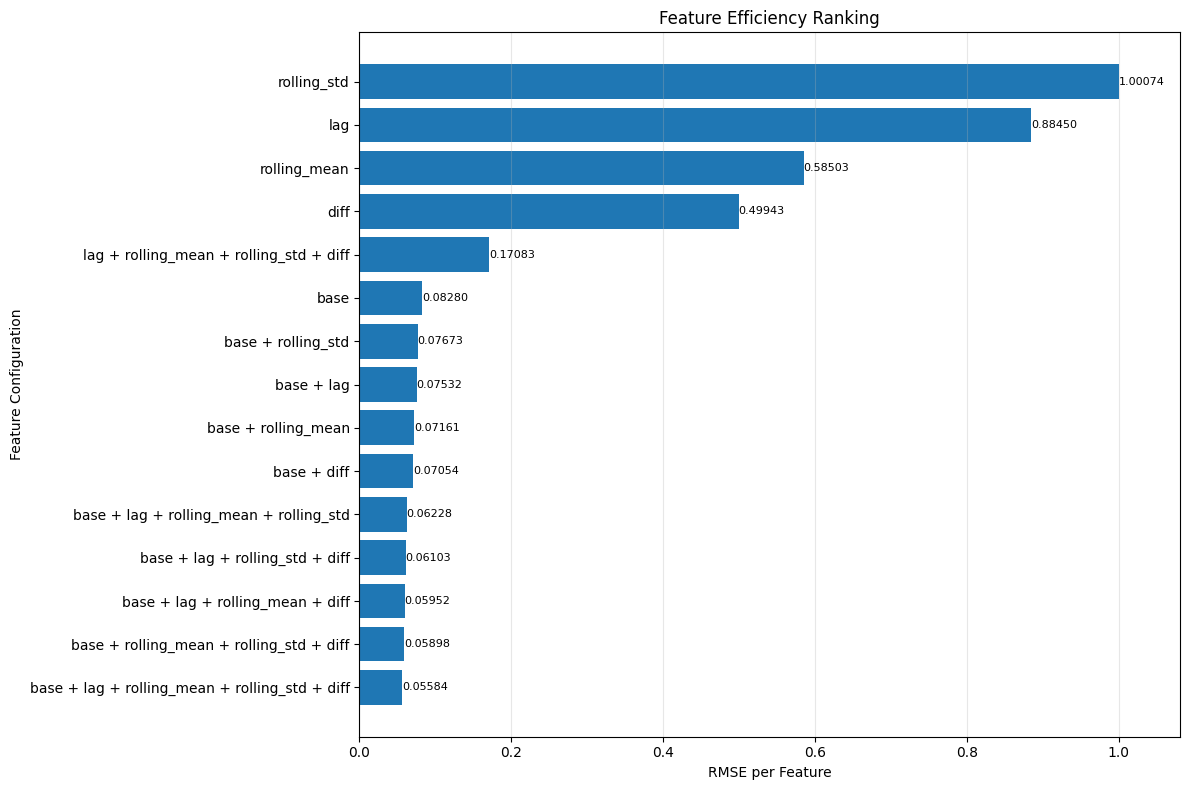

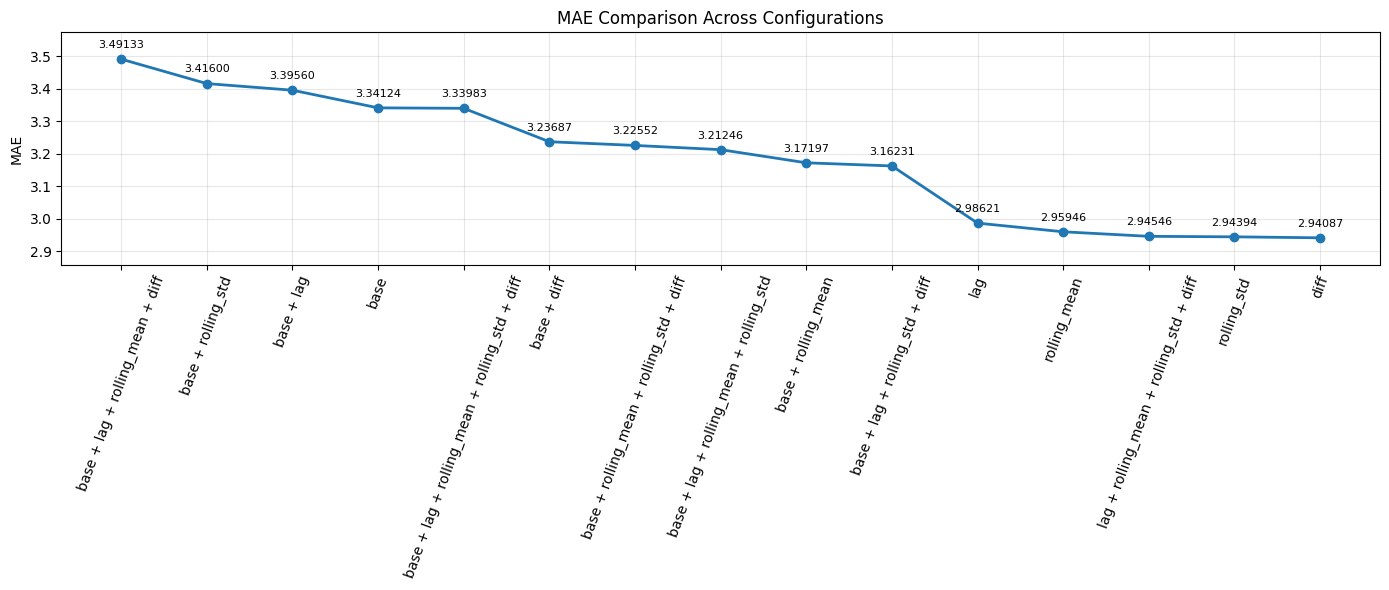

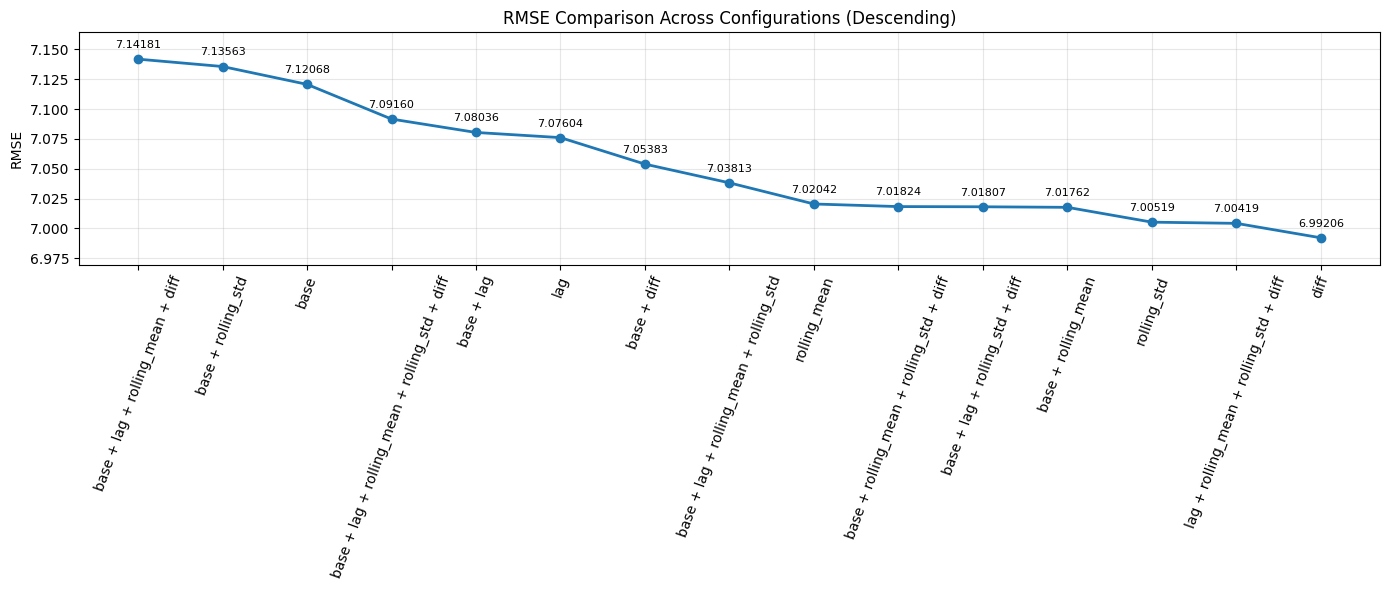

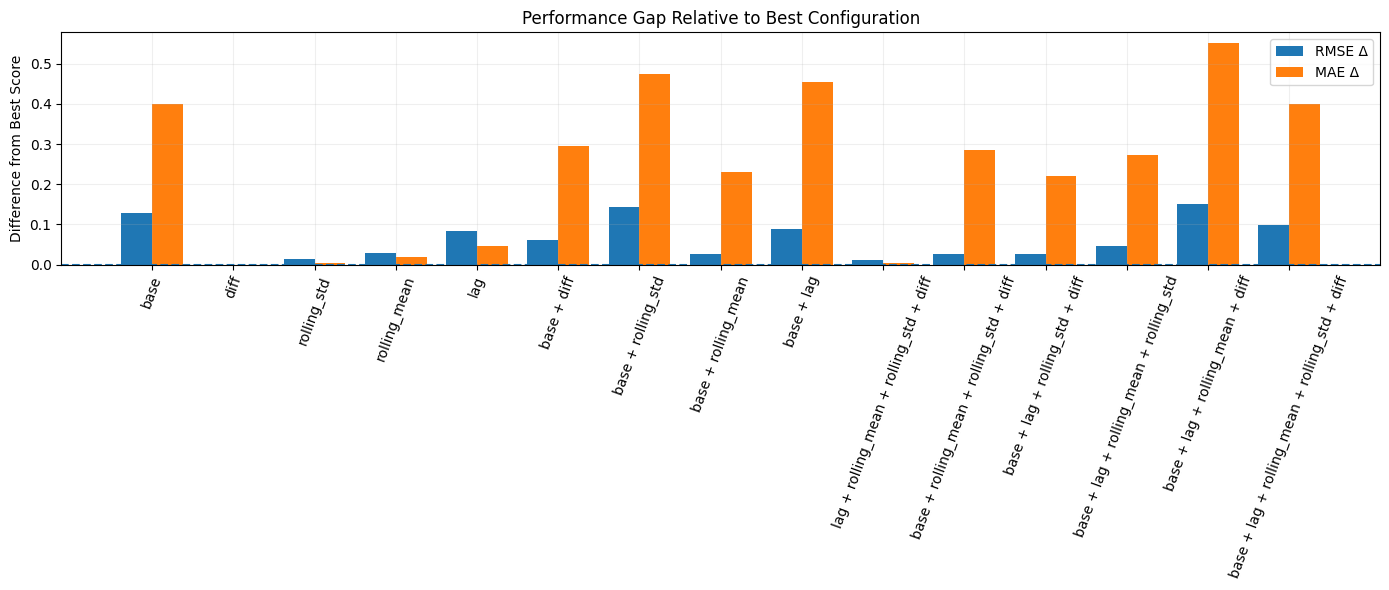

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
#!pip install adjustText
#from adjustText import adjust_text

results_df = results_df.sort("weighted_rmse")
configs = results_df["config"].to_list()
weighted_rmse = results_df["weighted_rmse"].to_list()
rmse = results_df["rmse"].to_list()
mae = results_df["mae"].to_list()
num_features = results_df["num_features"].to_list()
x = np.arange(len(configs))
'''
# 1. HORIZONTAL BAR CHART OF WEIGHTED RMSE

plt.figure(figsize=(12, 8))

sorted_idx = sorted(range(len(weighted_rmse)), key=lambda i: weighted_rmse[i], reverse=True)

configs_sorted = [configs[i] for i in sorted_idx]
rmse_sorted = [weighted_rmse[i] for i in sorted_idx]


plt.barh(configs_sorted, rmse_sorted)

plt.gca().invert_yaxis()


plt.xlim(0, max(rmse_sorted) * 1.1)

plt.title("Ablation Study Ranking by Weighted RMSE")
plt.xlabel("Weighted RMSE")
plt.ylabel("Feature Configuration")


for i, v in enumerate(rmse_sorted):
    plt.text(v, i, f"{v:.5f}", va="center")

plt.tight_layout()
plt.show()
print(" ")
'''
'''
# 2. PERFORMANCE VS FEATURE COUNT

xf = results_df["num_features"].to_list()
yf = results_df["weighted_rmse"].to_list()
labels = results_df["config"].to_list()

plt.figure(figsize=(11, 8))

plt.scatter(xf, yf, s=100)


placed_positions = []

for i, label in enumerate(labels):

    x_offset = -22
    y_offset = 6


    for px, py in placed_positions:

        if abs(xf[i] - px) < 6 and abs(yf[i] - py) < 0.04:
            y_offset += 4

    plt.annotate(
        label,
        (xf[i], yf[i]),
        textcoords="offset points",
        xytext=(x_offset, y_offset),
        fontsize=8
    )

    placed_positions.append((xf[i], yf[i]))


z = np.polyfit(xf, yf, 1)
p = np.poly1d(z)

plt.plot(
    sorted(xf),
    p(sorted(xf)),
    linestyle="dotted"
)


plt.title("Performance vs Feature Count")
plt.xlabel("Number of Features")
plt.ylabel("Weighted RMSE")

plt.grid(alpha=0.3)
plt.xlim(min(xf) - 5, max(xf) + 38)
plt.tight_layout()

plt.show()
print(" ")
'''
# 3. FEATURE EFFICIENCY BAR CHART

efficiency = [
    r / f if f > 0 else np.nan
    for r, f in zip(rmse, num_features)
]

sorted_idx = np.argsort(efficiency)[::-1]

sorted_configs = [configs[i] for i in sorted_idx]
sorted_efficiency = [efficiency[i] for i in sorted_idx]


plt.figure(figsize=(12, 8))

bars = plt.barh(
    sorted_configs,
    sorted_efficiency
)

plt.gca().invert_yaxis()


for i, v in enumerate(sorted_efficiency):
    plt.text(
        v,
        i,
        f"{v:.5f}",
        va="center",
        fontsize=8
    )

plt.xlabel("RMSE per Feature")
plt.ylabel("Feature Configuration")

plt.title("Feature Efficiency Ranking")

plt.grid(axis="x", alpha=0.3)
plt.xlim(0, max(sorted_efficiency) * 1.08)
plt.tight_layout()
plt.show()
print(" ")

# 4. MAE COMPARISON

sorted_idx = np.argsort(mae)[::-1]

mae_sorted = [mae[i] for i in sorted_idx]
configs_sorted = [configs[i] for i in sorted_idx]

x_sorted = np.arange(len(mae_sorted))

plt.figure(figsize=(14, 6))

plt.plot(x_sorted, mae_sorted, marker="o", linewidth=2)

padding = (max(mae_sorted) - min(mae_sorted)) * 0.15

plt.ylim(
    min(mae_sorted) - padding,
    max(mae_sorted) + padding
)


for i, v in enumerate(mae_sorted):
    plt.annotate(
        f"{v:.5f}",
        (x_sorted[i], v),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

plt.xticks(x_sorted, configs_sorted, rotation=70)

plt.ylabel("MAE")
plt.title("MAE Comparison Across Configurations")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(" ")


# 5. RMSE COMPARISON
sorted_data = sorted(
    zip(configs, rmse),
    key=lambda t: t[1],
    reverse=True
)

configs_sorted, rmse_sorted = zip(*sorted_data)

x = range(len(configs_sorted))

plt.figure(figsize=(14, 6))

plt.plot(x, rmse_sorted, marker="o", linewidth=2)

padding = (max(rmse_sorted) - min(rmse_sorted)) * 0.15

plt.ylim(
    min(rmse_sorted) - padding,
    max(rmse_sorted) + padding
)

for i, v in enumerate(rmse_sorted):
    plt.annotate(
        f"{v:.5f}",
        (x[i], v),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=8
    )

plt.xticks(x, configs_sorted, rotation=70)

plt.ylabel("RMSE")
plt.title("RMSE Comparison Across Configurations (Descending)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(" ")

# 6. DELTA FROM BEST MODEL

best_rmse = min(rmse)
best_mae = min(mae)

rmse_delta = [v - best_rmse for v in rmse]
mae_delta = [v - best_mae for v in mae]

fig, ax = plt.subplots(figsize=(14, 6))

import numpy as np

x = np.arange(len(configs_sorted))

width = 0.38

ax.bar(x - width/2, rmse_delta, width=width, label="RMSE Δ")
ax.bar(x + width/2, mae_delta, width=width, label="MAE Δ")
ax.axhline(0, linestyle="--")

plt.xticks(x, configs, rotation=70)

plt.ylabel("Difference from Best Score")
plt.title("Performance Gap Relative to Best Configuration")

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


## Per-Horizon Models

In [ ]:
horizons = [1, 3, 10, 25]

def evaluate_horizon_model(
    train_df,
    horizon_value,
    model,
    features,
    target,
    weight,
    splits
):

    # -----------------------------------------
    # Filter horizon
    # -----------------------------------------
    df_h = train_df.filter(pl.col(HORIZON) == horizon_value)

    print(f"\n===== Horizon {horizon_value} =====")
    print(df_h.shape)

    # -----------------------------------------
    # Build matrices
    # -----------------------------------------
    X_h = df_h.select(features)
    y_h = df_h.select(target)
    w_h = df_h.select(weight)

    # -----------------------------------------
    # Time splits
    # -----------------------------------------
    tscv = TimeSeriesSplit(n_splits=5, gap=50)
    splits_h = list(tscv.split(X_h))

    # -----------------------------------------
    # Train
    # -----------------------------------------
    oof_preds = train_model(
        X_h,
        y_h,
        w_h,
        splits_h,
        model
    )

    # -----------------------------------------
    # Metrics
    # -----------------------------------------

    fold_scores, mean_rmse, mean_mae = (
        compute_fold_metrics(
            y_h,
            oof_preds,
            splits_h
        )
    )

    weighted_score = weighted_rmse(
        y_h.to_numpy().flatten(),
        oof_preds,
        w_h.to_numpy().flatten()
    )

    print(f"RMSE: {mean_rmse:.4f}")
    print(f"MAE: {mean_mae:.4f}")
    print(f"Weighted: {weighted_score:.6f}")

    return {
        "horizon": horizon_value,
        "rmse": mean_rmse,
        "mae": mean_mae,
        "weighted": weighted_score
    }

In [ ]:
results = []

for h in [1, 3, 10, 25]:

    result = evaluate_horizon_model(
        train_df=train_df,
        horizon_value=h,
        model=xgboost_model,
        features=FEATURES,
        target=TARGET,
        weight=WEIGHT,
        splits=None
    )

    results.append(result)


===== Horizon 1 =====
(139153, 94)
RMSE: 2.6680
MAE: 1.3553
Weighted: 0.000000

===== Horizon 3 =====
(138228, 94)
RMSE: 4.1999
MAE: 2.1402
Weighted: 0.000000

===== Horizon 10 =====
(133801, 94)
RMSE: 7.3694
MAE: 3.8997
Weighted: 0.000000

===== Horizon 25 =====
(122559, 94)
RMSE: 11.3721
MAE: 6.1362
Weighted: 0.000000


shape: (4, 4)
┌─────────┬───────────┬──────────┬──────────┐
│ horizon ┆ rmse      ┆ mae      ┆ weighted │
│ ---     ┆ ---       ┆ ---      ┆ ---      │
│ i64     ┆ f64       ┆ f64      ┆ f64      │
╞═════════╪═══════════╪══════════╪══════════╡
│ 1       ┆ 2.668016  ┆ 1.355324 ┆ 0.0      │
│ 3       ┆ 4.199949  ┆ 2.140239 ┆ 0.0      │
│ 10      ┆ 7.369353  ┆ 3.899705 ┆ 0.0      │
│ 25      ┆ 11.372087 ┆ 6.136192 ┆ 0.0      │
└─────────┴───────────┴──────────┴──────────┘


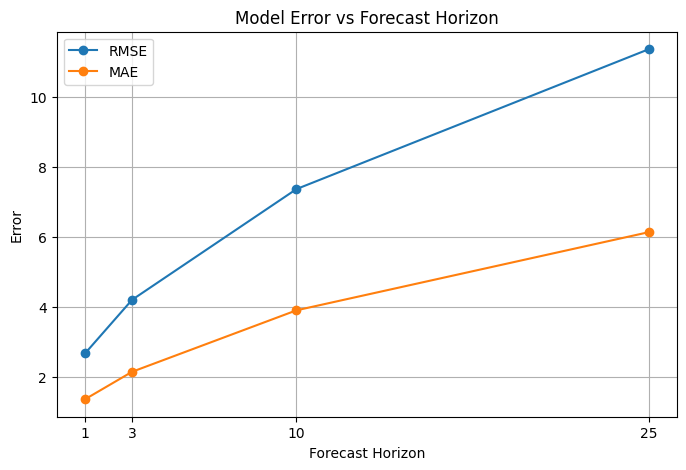

In [ ]:
results_df = pl.DataFrame(results)
print(results_df)

import matplotlib.pyplot as plt

# Sort by horizon just in case
plot_df = results_df.sort("horizon")

# Extract values
horizons = plot_df["horizon"].to_list()
rmse_scores = plot_df["rmse"].to_list()
mae_scores = plot_df["mae"].to_list()

# Create plot
plt.figure(figsize=(8, 5))

plt.plot(
    horizons,
    rmse_scores,
    marker="o",
    label="RMSE"
)

plt.plot(
    horizons,
    mae_scores,
    marker="o",
    label="MAE"
)

# Labels
plt.xlabel("Forecast Horizon")
plt.ylabel("Error")
plt.title("Model Error vs Forecast Horizon")

# Ensure exact horizon ticks appear
plt.xticks(horizons)

# Grid + legend
plt.grid(True)
plt.legend()

plt.show()

In [27]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sklearn.base import clone

# =========================================================
# CONFIG
# =========================================================

results = []

for h in horizons:

    print(f"\n===== Horizon {h} =====")

    # -----------------------------------------
    # Filter horizon
    # -----------------------------------------
    df_h = train_df.filter(
        pl.col(HORIZON) == h
    )

    # -----------------------------------------
    # Build matrices
    # -----------------------------------------
    X_h_pl = df_h.select(FEATURES)

    X_h = X_h_pl.to_pandas()

    y_h = (
        df_h[TARGET]
        .to_pandas()
        .values
        .ravel()
    )

    # =====================================================
    # CORRELATION
    # =====================================================

    corr_values = []

    for feature in FEATURES:

        corr = (
            df_h
            .select(
                pl.corr(feature, TARGET)
            )
            .item()
        )

        corr_values.append(corr)

    # =====================================================
    # XGBOOST IMPORTANCE
    # =====================================================

    model_h = clone(xgboost_model)

    model_h.fit(X_h, y_h)

    importances = model_h.feature_importances_

    # =====================================================
    # COMBINE
    # =====================================================

    feature_df = pd.DataFrame({
        "feature": FEATURES,
        "correlation": corr_values,
        "abs_correlation": np.abs(corr_values),
        "importance": importances
    })

    # -----------------------------------------
    # Rankings
    # -----------------------------------------

    feature_df["corr_rank"] = (
        feature_df["abs_correlation"]
        .rank(ascending=False)
    )

    feature_df["importance_rank"] = (
        feature_df["importance"]
        .rank(ascending=False)
    )

    # -----------------------------------------
    # Combined score
    # -----------------------------------------

    feature_df["combined_score"] = (
        (
            1 / feature_df["corr_rank"]
        )
        +
        (
            1 / feature_df["importance_rank"]
        )
    )

    feature_df["horizon"] = h

    # -----------------------------------------
    # Sort
    # -----------------------------------------

    feature_df = feature_df.sort_values(
        "combined_score",
        ascending=False
    )

    print("\nTop Combined Features:")
    print(
        feature_df[
            [
                "feature",
                "correlation",
                "importance",
                "combined_score"
            ]
        ].head(15)
    )

    results.append(feature_df)

# =========================================================
# FINAL DATAFRAME
# =========================================================

feature_diagnostics_df = pd.concat(
    results,
    ignore_index=True
)


===== Horizon 1 =====

Top Combined Features:
       feature  correlation  importance  combined_score
28  feature_ac     0.002492    0.022284        1.020833
77  feature_bz     0.044646    0.007980        1.013889
78  feature_ca     0.003082    0.019897        0.526316
81  feature_cd     0.043417    0.004878        0.512500
17   feature_r    -0.000143    0.019800        0.345238
31  feature_af    -0.023570    0.003692        0.344961
16   feature_q    -0.001038    0.018416        0.263514
20   feature_u    -0.023016    0.003890        0.261765
66  feature_bo    -0.016737    0.008968        0.214493
52  feature_ba     0.000873    0.018256        0.213333
24   feature_y    -0.003176    0.017308        0.193694
11   feature_l    -0.010745    0.014783        0.191667
64  feature_bm    -0.015582    0.005288        0.179325
40  feature_ao    -0.002940    0.016730        0.167247
79  feature_cb     0.007019    0.015713        0.158824

===== Horizon 3 =====

Top Combined Features:
       fea